In [1]:
%pip install matplotlib pandas geopandas  pyfixest
%pip install jinja2 statsmodels


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


# Loading

In [2]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
import os
import geopandas as gpd
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import argparse
from pathlib import Path
import seaborn as sns
import statsmodels.api as sm


K = -1




# # Set the width of your LaTeX document in points
document_width_pt = 511.  # Adjust this according to your LaTeX template
#plt.rc('text', usetex=True)
plt.rc('font', family='serif')
toulouse_color = (132/255, 46/255, 27/255)
missing_color = (0/255, 0/255, 0/255)
label_size = 18
font_size = 15  # Adjust according to your preference
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size,
    "axes.titlesize": font_size+2,
    "xtick.labelsize": font_size-3,
    "ytick.labelsize": font_size-3,
    "legend.fontsize": font_size-3,
    "legend.title_fontsize": font_size,
    "figure.titlesize": font_size,
})


def plot_map(df, col_name, ax, fig, vmin=None, vmax=None, ze_shocked=None, add_cbar=True, norm=None, cmap="viridis"):
    
    tmp = france.merge(df, on="ze2010", how="left")
    tmp[col_name].fillna(0, inplace=True)
    
    if vmin is None:
        vmin = df.query(f'{col_name} > 0')[col_name].min()
    if vmax is None:
        vmax = df[col_name].max()
    
    if norm is None:
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    
    tmp.query(f'{col_name} == 0').plot(color="gray", ax=ax)
    tmp.query(f'{col_name} > 0').plot(column=col_name, ax=ax, norm=norm, cmap=cmap, edgecolor="black")
    
    # Inset for IDF
    ax_inset = inset_axes(ax, width="65%", height="65%", loc="upper right",
                          bbox_to_anchor=(0.745, 0.775, 0.25, 0.25), 
                          bbox_transform=ax.transAxes, borderpad=1)
    data_idf = tmp[tmp['ze2010'].isin(idf_ze)]
    data_idf.query(f'{col_name} == 0').plot(color="gray", ax=ax_inset)
    data_idf.query(f'{col_name} > 0').plot(column=col_name, ax=ax_inset, norm=norm, cmap=cmap, edgecolor="black")
    
    if ze_shocked is not None:
        tmp.query(f'ze2010 == "{ze_shocked}"').plot(facecolor="none", ax=ax, edgecolor="red", hatch="//")
        if ze_shocked in idf_ze:
            data_idf.query(f'ze2010 == "{ze_shocked}"').plot(facecolor="none", ax=ax_inset, edgecolor="red", hatch="//")
    
    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax.set_xlim(-5, 10)
    ax.set_ylim(42, 52)
    ax.set_xticks([])
    ax.set_yticks([])
    
    if add_cbar:
        add_colorbar(ax, fig, norm)
    
    return norm

def get_figsize(document_width_pt = document_width_pt, wf=1, hf=0.5):
    """Parameters:
      - wf [float]:  width fraction in columnwidth units
      - hf [float]:  height fraction in columnwidth units.
                     Set by default to golden ratio.
      - columnwidth [float]: width of the column in latex. Get this from LaTeX 
                             using \showthe\columnwidth
    Returns:  [fig_width,fig_height]: that should be given to matplotlib
    """
    fig_width_pt = document_width_pt*wf
    inches_per_pt = 1.0/72.27               # Convert pt to inch
    fig_width = fig_width_pt*inches_per_pt  # width in inches
    fig_height = fig_width*hf      # height in inches
    return [fig_width, fig_height]



# Plots


def load_pi_r(emp_pi_r):
    pi_r = emp_pi_r
    pi_r = np.array([1-sum(pi_r)] + list(pi_r))
    df = filter_N_upstream_df[["ze2010","pi_r"]].drop_duplicates()
    df.loc[~df.pi_r.isna(),"sim_pi_r"] = pi_r
    df.pi_r.fillna(0,inplace = True)
    df.sim_pi_r.fillna(0,inplace = True)
    return df



def plot_downstream(df,col_name,ax,fig):

    tmp = france.merge(df,on = "ze2010",how = "left")
    tmp[col_name].fillna(0,inplace = True)
    
    if col_name != "productivity":
        vmin = min(df.query('pi_r >0')["pi_r"].to_list())#+df.query('sim_pi_r >0')["sim_pi_r"].to_list())
        vmax = max(df["pi_r"].to_list()+df["sim_pi_r"].to_list())
        norm = mcolors.LogNorm(vmin=vmin, vmax=vmax)
    else: 
        vmin,vmax = min(df.query('productivity >0').productivity),max(df['productivity'])
        norm = mcolors.Normalize(vmin=vmin, vmax=vmax)
        print(df.productivity.describe())

    tmp.query(col_name+' == 0').plot(color = "gray",ax=ax)
    tmp.query(col_name+' > 0').plot(column = col_name,ax=ax,norm = norm, cmap = "viridis",edgecolor ="black")

    ax_inset = inset_axes(ax, width="65%", height="65%", loc="upper right",bbox_to_anchor=(0.745, 0.775, 0.25, 0.25), bbox_transform=ax.transAxes, borderpad=1)  
    data_idf = tmp[tmp['ze2010'].isin(idf_ze)]
    data_idf.query(col_name+' == 0').plot(color = "gray",ax=ax_inset)
    data_idf.query(col_name+' > 0').plot(column = col_name,ax=ax_inset,norm = norm, cmap = "viridis",edgecolor ="black")

    ax_inset.set_xticks([])
    ax_inset.set_yticks([])
    ax.set_xlim(-5, 10)
    ax.set_ylim(42, 52)
    ax.set_xticks([])
    ax.set_yticks([])

    add_colorbar(ax,fig,norm)
    return norm

def load_productivity(file_name):
    prod = np.load(os.path.join(folder,f"{file_name}.npy"))
    df = filter_N_upstream_df[["ze2010","pi_r"]].drop_duplicates()
    df.loc[~df.pi_r.isna(),"productivity"] = prod
    df.productivity.fillna(0,inplace = True)
    return df

def add_colorbar(ax,fig,norm):
    sm = plt.cm.ScalarMappable(cmap="viridis", norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal", fraction=0.02, pad=0.04, aspect=50, format='%1.4f')
    cbar.minorticks_off()

def load_productivity(productivity):
    prod = productivity
    df = filter_N_upstream_df[["ze2010","pi_r"]].drop_duplicates()
    df.loc[~df.pi_r.isna(),"productivity"] = prod
    df.productivity.fillna(0,inplace = True)
    return df

def unpack_simulated_moments(sim_moments, empirical_moments):
    keys = [
        "agg_labor_share",
        "agg_industry_share",
        "emp_gamma_ls",
        "reg_coef",
        "emp_pi_r"
    ]

    sizes = [m.size for m in empirical_moments]
    splits = np.cumsum(sizes)[:-1]
    blocks = np.split(sim_moments, splits, axis=0)

    return {
        k: b.reshape(m.shape + (b.shape[1],))
        for k, m, b in zip(keys, empirical_moments, blocks)
    }


def unpack_params(params, S = 9, R_downstream = 35):
    """
    This function takes a vector of parameters and returns the parameters
    as separated variables.
    """

    beta = params[0:5]
    labor_share_tech = params[5]

    input_share_tech = params[6:6+S]
    input_share_tech = input_share_tech / np.sum(input_share_tech)

    productivity_ = params[6+S : 6+S+R_downstream]
    T_ = params[6+S+R_downstream :]

    return {"beta":beta, "labor_share_tech":labor_share_tech, "input_share_tech":input_share_tech, "productivity":productivity_, "T":T_}
    
def bubble_scatter(
    ax, x, y, xlabel, ylabel, title,
    size_scale=300,
    regression_line=False,
    weighted_regression=True,
    weights=None
):
    mask = x > 0
    x, y = x[mask], y[mask]

    sizes = size_scale * x / x.max()
    lims = [min(x.min(), y.min()) * 1.2, max(x.max(), y.max()) * 1.2]

    data = pd.DataFrame({"x": x, "y": y})

    ax.scatter(
        x, y,
        s=sizes,
        alpha=0.6,
        edgecolor="black",
        color=toulouse_color
    )

    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(linestyle="dashed", alpha=0.5)

    # -------------------
    # Regression section
    # -------------------
    if weighted_regression:
        # Default weights: proportional to x (can be changed)
        if weights is None:
            weights = x

        model = sm.WLS.from_formula(
            'y ~ 0 + x',
            data=data,
            weights=weights
        )
    else:
        model = sm.OLS.from_formula('y ~ 0 + x', data=data)

    results = model.fit()
    b = results.params[0]

    ax.text(
        0.98, 0.09,
        fr'Coefficient: ${np.round(b, 3)}$',
        ha='right', va='bottom',
        fontsize=10,
        transform=ax.transAxes
    )

    ax.text(
        0.98, 0.01,
        fr't-stat: ${np.round(results.tvalues[0], 1)}$',
        ha='right', va='bottom',
        fontsize=10,
        transform=ax.transAxes
    )

    # -------------------
    # Lines
    # -------------------
    if regression_line:
        X = np.linspace(0, lims[1], 100)
        Y = b * X
        ax.plot(X, Y, linestyle='--', color='green')
    else:
        ax.plot(lims, lims, color="black")

    sns.despine()



<>:87: SyntaxWarning: invalid escape sequence '\s'
<>:87: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_124402/163885431.py:87: SyntaxWarning: invalid escape sequence '\s'
  using \showthe\columnwidth


In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
from pathlib import Path

def load_industry_data(industry, industry_name):
    """
    Load all necessary data for a given industry.
    
    Parameters:
    -----------
    industry : str
        Industry code (e.g., "auto_23", "aero")
    industry_name : str
        Industry name (e.g., "auto", "aero")
    
    Returns:
    --------
    dict with all loaded data and derived variables
    """
    
    # =========================================================================
    # PATHS
    # =========================================================================
    input_folder = Path(f"../baseline_{industry}")
    folder = Path(f"../reporting_{industry}/")
    
    # Downstream sector
    d = "C30C" if industry_name == "aero" else "C29A"
    
    # =========================================================================
    # COEFFICIENTS
    # =========================================================================
    coefs = pd.read_csv(input_folder / "stats.csv")
    agg_labor_share = coefs.loc[1, "value"]
    epsilon = coefs.loc[0, "value"]
    
    # =========================================================================
    # ARRAYS
    # =========================================================================
    agg_industry_share = np.load(input_folder / "input_share.npy")
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy").T
    emp_pi_r = np.load(input_folder / "emp_pi_r.npy")[1:]
    reg_coef = np.load(input_folder / "reg_coef.npy")
    
    # =========================================================================
    # REFERENCE EMPIRICAL MOMENTS
    # =========================================================================
    reference_empirical_moments = [
        np.array([agg_labor_share]),
        agg_industry_share[1:],
        emp_gamma_ls,
        reg_coef,
        emp_pi_r
    ]
    
    # =========================================================================
    # ILE-DE-FRANCE ZONES
    # =========================================================================
    idf_ze = [
        '1101', '1111', '1102', '1104', '1118', '1115', '1116', '1105',
        '1117', '1110', '1119', '1112', '1103', '1109', '1106', '1114',
        '1113', '1108', '1107'
    ]
    
    # =========================================================================
    # FILTER DATA
    # =========================================================================
    filter_N_upstream_df = pd.read_csv(input_folder / "filter_N_upstream.csv")
    filter_N_upstream_df['ze2010'] = filter_N_upstream_df['ze2010'].astype(str).str.zfill(4)
    
    # =========================================================================
    # DISTANCES AND GEOGRAPHY
    # =========================================================================
    distances = np.load(input_folder / "full_distances.npy")
    france = gpd.read_file(input_folder / "france.shp").sort_values(by='ze2010')
    
    # Build distance reference dataframe
    ref = pd.DataFrame(
        distances[:297, :297], 
        index=france["ze2010"].values, 
        columns=france["ze2010"].values
    )
    ref.reset_index(inplace=True)
    ref.rename(columns={'index': 'ze2010_i'}, inplace=True)
    ref = ref.melt(id_vars='ze2010_i', var_name='ze2010_j', value_name='M_ij')
    
    # =========================================================================
    # SIMULATED MOMENTS
    # =========================================================================
    empirical_moments = np.load(folder / "empirical_moments.npy")
    best_simulated_moments = np.load(folder / "best_simulated_moments.npy")
    best_params = np.load(folder / "best_parameters_list.npy")
    try:panel_df = pd.read_csv(folder/ "simulated_panel.csv")
    except : panel_df = None
    # Unpack moments
    best_simulated_moments_dict = unpack_simulated_moments(
        best_simulated_moments, 
        reference_empirical_moments
    )
    empirical_moments_dict = unpack_simulated_moments(
        empirical_moments.T, 
        reference_empirical_moments
    )
    
    # =========================================================================
    # RETURN ALL DATA
    # =========================================================================
    return {
        # Paths
        'input_folder': input_folder,
        'folder': folder,
        
        # Industry info
        'industry': industry,
        'industry_name': industry_name,
        'd': d,
        
        # Coefficients
        'coefs': coefs,
        'agg_labor_share': agg_labor_share,
        'epsilon': epsilon,
        
        # Arrays
        'agg_industry_share': agg_industry_share,
        'emp_gamma_ls': emp_gamma_ls,
        'emp_pi_r': emp_pi_r,
        'reg_coef': reg_coef,
        
        # Moments
        'reference_empirical_moments': reference_empirical_moments,
        'empirical_moments': empirical_moments,
        'best_simulated_moments': best_simulated_moments,
        'best_params': best_params,
        'best_simulated_moments_dict': best_simulated_moments_dict,
        'empirical_moments_dict': empirical_moments_dict,

        # Regression 
        'panel_df':panel_df,
        
        # Geography
        'idf_ze': idf_ze,
        'filter_N_upstream_df': filter_N_upstream_df,
        'distances': distances,
        'france': france,
        'ref': ref,
    }


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

# Load data
data = load_industry_data("aero", "aero")

# Unpack variables (optional - can also access via data['variable_name'])
input_folder = data['input_folder']
folder = data['folder']
d = data['d']
agg_labor_share = data['agg_labor_share']
epsilon = data['epsilon']
agg_industry_share = data['agg_industry_share']
emp_gamma_ls = data['emp_gamma_ls']
emp_pi_r = data['emp_pi_r']
reg_coef = data['reg_coef']
reference_empirical_moments = data['reference_empirical_moments']
idf_ze = data['idf_ze']
filter_N_upstream_df = data['filter_N_upstream_df']
distances = data['distances']
france = data['france']
ref = data['ref']
empirical_moments = data['empirical_moments']
best_simulated_moments = data['best_simulated_moments']
best_params = data['best_params']
best_simulated_moments_dict = data['best_simulated_moments_dict']
empirical_moments_dict = data['empirical_moments_dict']
panel_df = data['panel_df']

# Or use a helper to unpack all at once
def unpack_data(data_dict):
    """Unpack data dictionary into global namespace."""
    return data_dict.values()

# Or more elegantly with locals().update() in a notebook:
# locals().update(data)

# Reporting

In [19]:
# Load and unpack in one step
industry_dict = {"auto":{"industry_label":"auto_23","industry_name":"auto"},
"aero":{"industry_label":"aero","industry_name":"aero"}}

data = load_industry_data(industry_dict['aero']['industry_label'], industry_dict['aero']['industry_name'])
globals().update(data)  # In a script
print(d)  # "C29A"


C30C


## Merging reporting tables

In [20]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

# Assuming unpack_simulated_moments is defined elsewhere in your codebase
# from your_module import unpack_simulated_moments

def load_industry_data(industry, industry_name):
    """Load all necessary data for a given industry."""
    input_folder = Path(f"../baseline_{industry}")
    folder = f"../reporting_{industry}/"
    
    # Load coefficients
    coefs = pd.read_csv(input_folder / "stats.csv")
    agg_labor_share = coefs.loc[1, "value"]
    epsilon = coefs.loc[0, "value"]
    
    # Load arrays
    agg_industry_share = np.load(input_folder / "input_share.npy")
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy").T
    emp_pi_r = np.load(input_folder / "emp_pi_r.npy")[1:]
    reg_coef = np.load(input_folder / "reg_coef.npy")
    
    # Reference empirical moments
    reference_empirical_moments = [
        np.array([agg_labor_share]),
        agg_industry_share[1:],
        emp_gamma_ls,
        reg_coef,
        emp_pi_r
    ]
    
    # Load filter data for industry names
    filter_N_upstream_df = pd.read_csv(os.path.join(input_folder, "filter_N_upstream.csv"))
    filter_N_upstream_df.ze2010 = filter_N_upstream_df.ze2010.astype(str).str.zfill(4)
    
    # Load simulated moments
    empirical_moments = np.load(os.path.join(folder, "empirical_moments.npy"))
    best_simulated_moments = np.load(os.path.join(folder, "best_simulated_moments.npy"))
    best_params = np.load(os.path.join(folder, "best_parameters_list.npy"))
    
    # Unpack moments
    best_simulated_moments_dict = unpack_simulated_moments(best_simulated_moments, reference_empirical_moments)
    empirical_moments_dict = unpack_simulated_moments(empirical_moments.T, reference_empirical_moments)
    
    return {
        'agg_labor_share': agg_labor_share,
        'agg_industry_share': agg_industry_share,
        'reg_coef': reg_coef,
        'filter_N_upstream_df': filter_N_upstream_df,
        'best_simulated_moments_dict': best_simulated_moments_dict,
        'empirical_moments_dict': empirical_moments_dict
    }


def generate_combined_table(industries_config, output_file="moments_comparison_combined.tex"):
    """
    Generate a combined LaTeX table with subcolumns for multiple industries.
    
    Parameters:
    -----------
    industries_config : list of dict
        Each dict contains: 'industry', 'industry_name', 'display_name'
        Example: [{'industry': 'auto_23', 'industry_name': 'auto', 'display_name': 'Car'},
                  {'industry': 'aero', 'industry_name': 'aero', 'display_name': 'Aerospace'}]
    """
    K = -1  # Use last iteration
    
    # Load data for all industries
    all_data = {}
    for config in industries_config:
        industry = config['industry']
        industry_name = config['industry_name']
        all_data[industry] = load_industry_data(industry, industry_name)
    
    # Load industry names
    name_A129 = pd.read_csv("../external/A129_name_fr_eng.csv")
    
    # Number of industries
    n_industries = len(industries_config)
    
    # Build column spec for siunitx
    col_spec = "l " + " ".join(["S[table-format=1.4] S[table-format=1.4]" for _ in range(n_industries)])
    
    # Build header with multicolumn for each industry
    header_row1 = " & " + " & ".join([f"\\multicolumn{{2}}{{c}}{{{config['display_name']}}}" for config in industries_config]) + " \\\\"
    
    # Cmidrule for each industry pair
    cmidrules = ""
    for i, _ in enumerate(industries_config):
        start_col = 2 + i * 2
        end_col = start_col + 1
        cmidrules += f"\\cmidrule(lr){{{start_col}-{end_col}}} "
    
    header_row2 = " & " + " & ".join(["{Emp.} & {Sim.}" for _ in industries_config]) + " \\\\"
    
    # === Panel A: Aggregate Labor Share ===
    panel_A_rows = []
    row_data = ["Aggregate Labor Share"]
    for config in industries_config:
        industry = config['industry']
        data = all_data[industry]
        emp_val = np.round(data['agg_labor_share'], 4)
        sim_val = np.round(data['best_simulated_moments_dict']['agg_labor_share'][:, K][0], 4)
        row_data.extend([emp_val, sim_val])
    panel_A_rows.append(row_data)
    
    # === Panel B: Aggregate Industry Shares ===
    # Get union of all A129 codes across industries
    all_A129_codes = set()
    for config in industries_config:
        industry = config['industry']
        data = all_data[industry]
        codes = list(data['filter_N_upstream_df']['A129'].drop_duplicates().sort_values())
        all_A129_codes.update(codes)
    all_A129_codes = sorted(all_A129_codes)
    
    # Create industry share dataframes for each industry
    industry_shares = {}
    for config in industries_config:
        industry = config['industry']
        data = all_data[industry]
        A129_codes = list(data['filter_N_upstream_df']['A129'].drop_duplicates().sort_values())
        sim_shares = [1 - np.sum(data['best_simulated_moments_dict']['agg_industry_share'][:, K])] + \
                     list(data['best_simulated_moments_dict']['agg_industry_share'][:, K])
        
        industry_shares[industry] = pd.DataFrame({
            "A129": A129_codes,
            "Empirical": list(np.round(data['agg_industry_share'], 4)),
            "Simulated": np.round(sim_shares, 4)
        })
    
    # Build Panel B rows
    panel_B_rows = []
    for code in all_A129_codes:
        sector_name = name_A129[name_A129['A129'] == code]['name'].values
        sector_name = sector_name[0] if len(sector_name) > 0 else "Non-upstream sector"
        
        row_data = [sector_name]
        for config in industries_config:
            industry = config['industry']
            df = industry_shares[industry]
            match = df[df['A129'] == code]
            if len(match) > 0:
                emp_val = match.iloc[0]['Empirical']
                sim_val = match.iloc[0]['Simulated']
            else:
                emp_val, sim_val = "---", "---"
            row_data.extend([emp_val, sim_val])
        panel_B_rows.append(row_data)
    
    # === Panel C: Regression Coefficients ===
    # Define coefficient names - use the superset (aero has more bins)
    all_coef_names = [r'$]20,50]$', r'$]50,100]$', r'$]100,150]$', r'$]150,200]$', r'$>200$']
    
    panel_C_rows = []
    for i, coef_name in enumerate(all_coef_names):
        row_data = [coef_name]
        for config in industries_config:
            industry = config['industry']
            data = all_data[industry]
            
            # Determine which coefficient index to use
            if industry == "aero":
                # Aero has 5 coefficients starting from ]20,50]
                coef_idx = i
            else:
                # # Auto has 4 coefficients starting from ]50,100]
                # if i == 0:  # ]20,50] not available for auto
                #     row_data.extend(["---", "---"])
                #     continue
                # else:
                    #coef_idx = i - 1  # Shift index for auto
                coef_idx = i 
            
            if coef_idx < len(data['reg_coef']):
                emp_val = np.round(data['reg_coef'][coef_idx], 3)
                sim_val = np.round(data['best_simulated_moments_dict']['reg_coef'][:, K][coef_idx], 3)
            else:
                emp_val, sim_val = "---", "---"
            row_data.extend([emp_val, sim_val])
        panel_C_rows.append(row_data)
    
    # === Generate LaTeX Table ===
    def format_value(val, decimals=4):
        """Format a value for LaTeX, handling '---' for missing data."""
        if val == "---" or (isinstance(val, float) and np.isnan(val)):
            return "{---}"
        return f"{val:.{decimals}f}"
    
    latex_table = r"""\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{""" + col_spec + r"""}
\toprule
""" + header_row1 + "\n" + cmidrules + "\n" + header_row2 + "\n"
    
    # Panel A
    latex_table += "\\midrule\n"
    latex_table += f"\\multicolumn{{{1 + 2*n_industries}}}{{l}}{{\\textbf{{Panel A: Aggregate Labor Share}}}} \\\\\n"
    latex_table += "\\midrule\n"
    for row in panel_A_rows:
        row_str = row[0] + " & " + " & ".join([format_value(v, 4) for v in row[1:]]) + " \\\\\n"
        latex_table += row_str
    
    # Panel B
    latex_table += "\\midrule\n"
    latex_table += f"\\multicolumn{{{1 + 2*n_industries}}}{{l}}{{\\textbf{{Panel B: Aggregate Industry Shares}}}} \\\\\n"
    latex_table += "\\midrule\n"
    for row in panel_B_rows:
        row_str = row[0] + " & " + " & ".join([format_value(v, 4) for v in row[1:]]) + " \\\\\n"
        latex_table += row_str
    
    # Panel C
    latex_table += "\\midrule\n"
    latex_table += f"\\multicolumn{{{1 + 2*n_industries}}}{{l}}{{\\textbf{{Panel C: Regression Coefficients}}}} \\\\\n"
    latex_table += "\\midrule\n"
    for row in panel_C_rows:
        row_str = row[0] + " & " + " & ".join([format_value(v, 3) for v in row[1:]]) + " \\\\\n"
        latex_table += row_str
    
    latex_table += "\\bottomrule\n"
    latex_table += r"""\end{tabular}

\vspace{0.3cm}
\caption*{\footnotesize \emph{Notes}: This table compares empirical moments with moments simulated from the model calibrated on each industry. ``Emp.'' = Empirical, ``Sim.'' = Simulated. Panel~A shows the aggregate labor share, Panel~B shows sectoral industry shares, and Panel~C shows regression coefficients estimated empirically using Equation~\ref{eq:reduced_form_spatialIO} on finer distance bins. ``---'' indicates the moment is not applicable for that industry. Shares are rounded to 4 decimals, coefficients to 3 decimals.}
\end{table}
"""
    
    # Save to file
    with open(output_file, "w") as f:
        f.write(latex_table)
    
    print(f"Combined table saved to: {output_file}")
    return latex_table


# === Main execution ===
if __name__ == "__main__":
    # Define industries to compare
    industries_config = [
        {'industry': 'auto_23', 'industry_name': 'auto', 'display_name': 'Car'},
        {'industry': 'aero', 'industry_name': 'aero', 'display_name': 'Aerospace'}
    ]
    
    # Generate combined table
    output_folder = "../reporting_combined/"
    os.makedirs(output_folder, exist_ok=True)
    
    latex_output = generate_combined_table(
        industries_config,
        output_file=os.path.join(output_folder, "moments_comparison_combined.tex")
    )
    
    print(latex_output)

Combined table saved to: ../reporting_combined/moments_comparison_combined.tex
\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{l S[table-format=1.4] S[table-format=1.4] S[table-format=1.4] S[table-format=1.4]}
\toprule
 & \multicolumn{2}{c}{Car} & \multicolumn{2}{c}{Aerospace} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} 
 & {Emp.} & {Sim.} & {Emp.} & {Sim.} \\
\midrule
\multicolumn{5}{l}{\textbf{Panel A: Aggregate Labor Share}} \\
\midrule
Aggregate Labor Share & 0.1880 & 0.1851 & 0.1572 & 0.1286 \\
\midrule
\multicolumn{5}{l}{\textbf{Panel B: Aggregate Industry Shares}} \\
\midrule
Rubber Manufacturing & 0.0463 & 0.0516 & {---} & {---} \\
Plastic Manufacturing & 0.0849 & 0.0840 & 0.0158 & 0.0003 \\
Forging \& Metal Machining & 0.1005 & 0.0996 & 0.0141 & 0.0151 \\
Instruments \& Appliances Manufacturing & {---} & {---} & 0.0730 & 0.0745 \\
Ot

## Table, maps and scatter plots

In [21]:
import os
import numpy as np
import pandas as pd

# --- Panel A: Aggregate Labor Share ---
panel_A = pd.DataFrame({
    "Sector": ["Aggregate Labor Share"],
    "Empirical": [np.round(agg_labor_share, 4)],
    "Simulated": [np.round(best_simulated_moments_dict['agg_labor_share'][:, K][0], 4)]
})

# --- Panel B: Aggregate Industry Shares ---
# Load industry names
name_A129 = pd.read_csv("../external/A129_name_fr_eng.csv")

# Simulated shares (including residual sector if needed)
sim_agg_industry_share = [1 - np.sum(best_simulated_moments_dict['agg_industry_share'][:, K])] + list(best_simulated_moments_dict['agg_industry_share'][:, K])

# Individual sector codes
A129_codes = list(filter_N_upstream_df['A129'].drop_duplicates().sort_values())

industry_share = pd.DataFrame({
    "A129": A129_codes,
    "Empirical": list(np.round(agg_industry_share, 4)),
    "Simulated": np.round(sim_agg_industry_share, 4)
})

# Merge with names
industry_share = industry_share.merge(name_A129, on="A129", how="left")
industry_share["name"] = industry_share["name"].fillna("Aggregate / Non-upstream sector")
industry_share = industry_share.rename(columns={"name": "Sector"})
industry_share = industry_share[["Sector", "Empirical", "Simulated"]]

# --- Panel C: Regression Coefficients ---

coef_names = [r'$]20,50]$', r'$]50,100]$', r'$]100,150]$', r'$]150,200]$', r'$ > 200$'] if industry == "aero" else [ r'$]50,100]$', r'$]100,150]$', r'$]150,200]$', r'$ > 200$']

panel_C = pd.DataFrame({
    "Coefficient": coef_names,
    "Empirical": np.round(reg_coef, 3),
    "Simulated": np.round(best_simulated_moments_dict['reg_coef'][:, K], 3)
})

# --- Generate LaTeX Table ---
def df_to_latex(panel, panel_name, col1_name):
    latex = f"\\multicolumn{{3}}{{l}}{{\\textbf{{{panel_name}}}}} \\\\\n"
    latex += "\\midrule\n"
    latex += f"{col1_name} & {{Empirical}} & {{Simulated}} \\\\\n"
    latex += "\\midrule\n"
    for i, row in panel.iterrows():
        latex += f"{row[0]} & {row[1]:.4f} & {row[2]:.4f} \\\\\n"
    latex += "\\bottomrule\n\\addlinespace[0.5em]\n"
    return latex

latex_table = r"""\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments}
\label{tab:moments_comparison_""" + f"{industry}" + r"""}
\renewcommand{\arraystretch}{1.2} % row spacing
\small
\begin{tabular}{
l
S[table-format=1.4] 
S[table-format=1.4]
}
\toprule
"""

latex_table += df_to_latex(panel_A, "Panel A: Aggregate Labor Share", "")
latex_table += df_to_latex(industry_share, "Panel B: Aggregate Industry Shares", "Sector")

# Panel C: Regression coefficients
latex_table += f"\\multicolumn{{3}}{{l}}{{\\textbf{{Panel C: Regression Coefficients}}}} \\\\\n"
latex_table += "\\midrule\n"
latex_table += "Coefficient & {Empirical} & {Simulated} \\\\\n"
latex_table += "\\midrule\n"
for i, row in panel_C.iterrows():
    latex_table += f"{row[0]} & {row[1]:.3f} & {row[2]:.3f} \\\\\n"
latex_table += "\\bottomrule\n"

latex_table += r"""\end{tabular}

\vspace{0.3cm}
\caption*{\footnotesize \emph{Notes}: This table compares empirical moments (Column~2) with moments simulated from the model calibrated on the """ + f"{industry_name}" + r""" industry. Panel A shows the aggregate labor share, Panel B shows sectoral industry shares, and Panel C shows regression coefficients estimated empirically using Equation~\ref{eq:reduced_form_spatialIO} on a finer distance bins. Shares are rounded to 4 decimals, coefficients to 3 decimals.}
\end{table}
"""

# Save to file
output_file = os.path.join(folder, f"moments_comparison_{industry}.tex")
with open(output_file, "w") as f:
    f.write(latex_table)


/tmp/ipykernel_124402/2044789981.py:51: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  latex += f"{row[0]} & {row[1]:.4f} & {row[2]:.4f} \\\\\n"
/tmp/ipykernel_124402/2044789981.py:78: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  latex_table += f"{row[0]} & {row[1]:.3f} & {row[2]:.3f} \\\\\n"


/tmp/ipykernel_124402/163885431.py:106: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df.pi_r.fillna(0,inplace = True)
/tmp/ipykernel_124402/163885431.py:107: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.

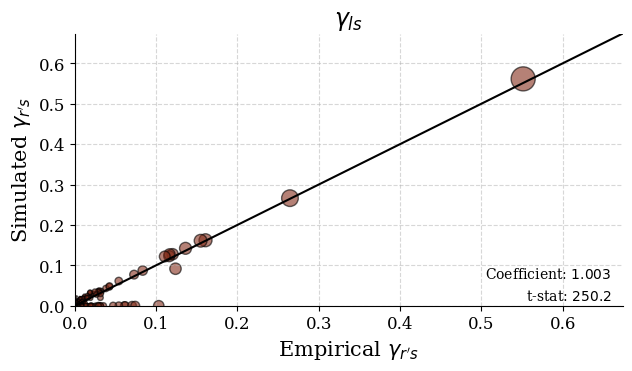

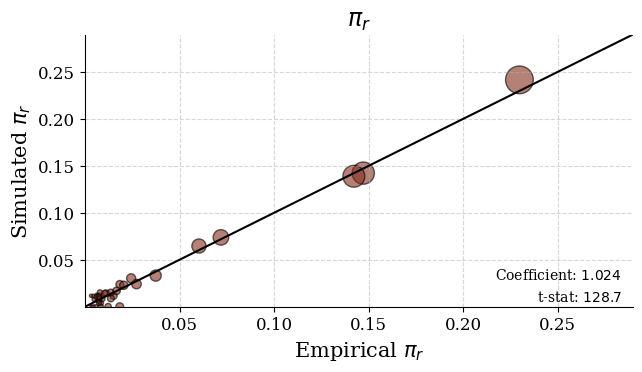

In [22]:
emp_g = empirical_moments_dict['emp_gamma_ls'].ravel()
sim_g = best_simulated_moments_dict['emp_gamma_ls'][:, :, K].ravel()

pi_r = load_pi_r(best_simulated_moments_dict['emp_pi_r'][:, K])

emp_pi = pi_r.pi_r.values
sim_pi = pi_r.sim_pi_r.values


    
fig, axs = plt.subplots(1, 1, figsize=get_figsize())

bubble_scatter(
    axs,
    emp_g,
    sim_g,
    r"Empirical $\gamma_{r's}$",
    r"Simulated $\gamma_{r's}$",
    r"$\gamma_{ls}$",regression_line = False
)

fig.savefig(os.path.join(folder, f'emp_sim_gamma_{industry}.pdf'), format='pdf', bbox_inches='tight')

fig, axs = plt.subplots(1, 1, figsize=get_figsize())

bubble_scatter(
    axs,
    emp_pi,
    sim_pi,
    r"Empirical $\pi_{r}$",
    r"Simulated $\pi_{r}$",
    r"$\pi_{r}$",
    size_scale=400,regression_line = False
)
fig.savefig(os.path.join(folder, f'emp_sim_pi_{industry}.pdf'), format='pdf', bbox_inches='tight')


/tmp/ipykernel_124402/163885431.py:115: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tmp[col_name].fillna(0,inplace = True)
/tmp/ipykernel_124402/163885431.py:115: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

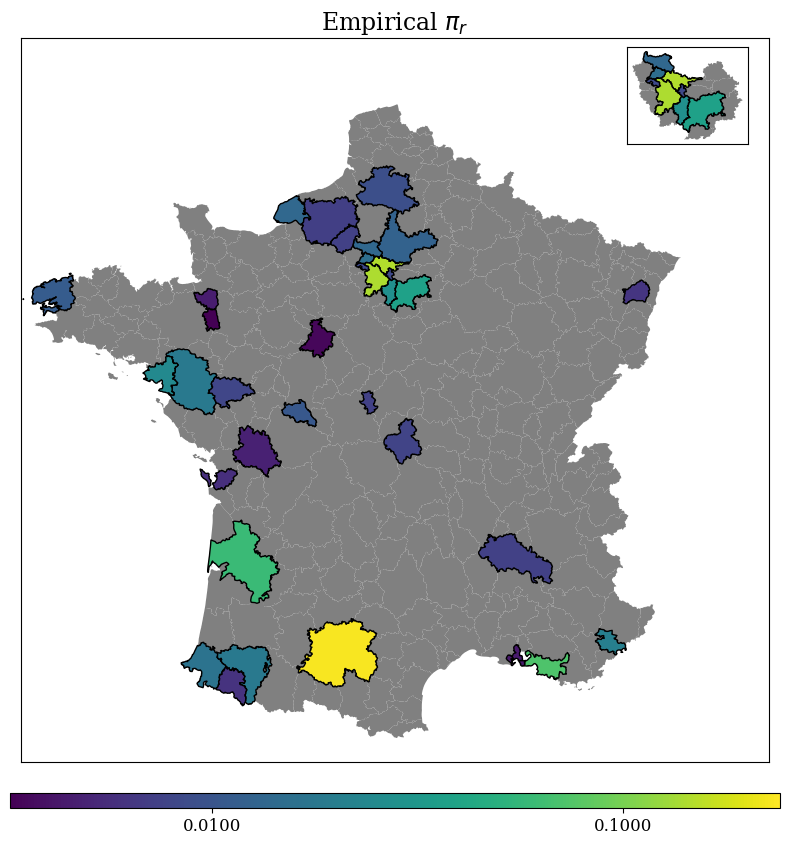

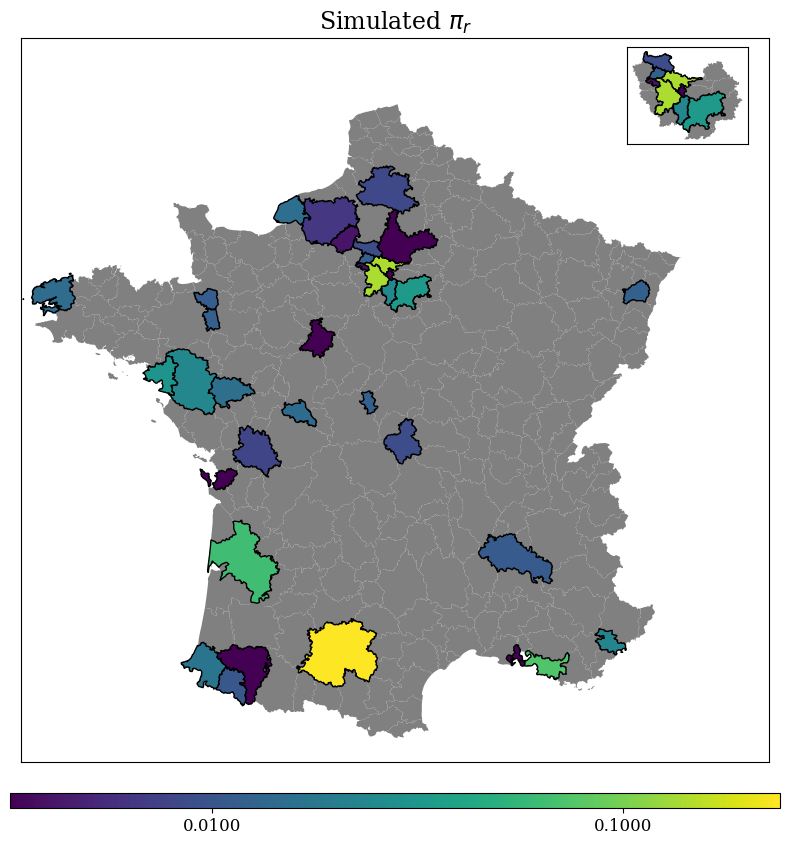

In [23]:
fig,axs = plt.subplots(1,1,figsize = (15,10))

plot_downstream(pi_r, "pi_r", axs,fig)
axs.set_title(r"Empirical $\pi_{r}$ ")
fig.savefig(os.path.join(folder, f"emp_pi_r_{industry}.png"), bbox_inches='tight')

fig,axs = plt.subplots(1,1,figsize = (15,10))
plot_downstream(pi_r, "sim_pi_r",axs,fig)
axs.set_title(r"Simulated $\pi_{r}$ ")
fig.savefig(os.path.join(folder, f"sim_pi_r_{industry}.png"), bbox_inches='tight')

## Merging reporting tables

In [11]:
import os
import numpy as np
import pandas as pd
from pathlib import Path

# Assuming unpack_simulated_moments is defined elsewhere in your codebase
# from your_module import unpack_simulated_moments

def load_industry_data(industry, industry_name):
    """Load all necessary data for a given industry."""
    input_folder = Path(f"../baseline_{industry}")
    folder = f"../reporting_{industry}/"
    
    # Load coefficients
    coefs = pd.read_csv(input_folder / "stats.csv")
    agg_labor_share = coefs.loc[1, "value"]
    epsilon = coefs.loc[0, "value"]
    
    # Load arrays
    agg_industry_share = np.load(input_folder / "input_share.npy")
    emp_gamma_ls = np.load(input_folder / "emp_gamma_ls.npy").T
    emp_pi_r = np.load(input_folder / "emp_pi_r.npy")[1:]
    reg_coef = np.load(input_folder / "reg_coef.npy")
    
    # Reference empirical moments
    reference_empirical_moments = [
        np.array([agg_labor_share]),
        agg_industry_share[1:],
        emp_gamma_ls,
        reg_coef,
        emp_pi_r
    ]
    
    # Load filter data for industry names
    filter_N_upstream_df = pd.read_csv(os.path.join(input_folder, "filter_N_upstream.csv"))
    filter_N_upstream_df.ze2010 = filter_N_upstream_df.ze2010.astype(str).str.zfill(4)
    
    # Load simulated moments
    empirical_moments = np.load(os.path.join(folder, "empirical_moments.npy"))
    best_simulated_moments = np.load(os.path.join(folder, "best_simulated_moments.npy"))
    best_params = np.load(os.path.join(folder, "best_parameters_list.npy"))
    
    # Unpack moments
    best_simulated_moments_dict = unpack_simulated_moments(best_simulated_moments, reference_empirical_moments)
    empirical_moments_dict = unpack_simulated_moments(empirical_moments.T, reference_empirical_moments)
    
    return {
        'agg_labor_share': agg_labor_share,
        'agg_industry_share': agg_industry_share,
        'reg_coef': reg_coef,
        'filter_N_upstream_df': filter_N_upstream_df,
        'best_simulated_moments_dict': best_simulated_moments_dict,
        'empirical_moments_dict': empirical_moments_dict
    }


def generate_combined_table(industries_config, output_file="moments_comparison_combined.tex"):
    """
    Generate a combined LaTeX table with subcolumns for multiple industries.
    
    Parameters:
    -----------
    industries_config : list of dict
        Each dict contains: 'industry', 'industry_name', 'display_name'
        Example: [{'industry': 'auto_23', 'industry_name': 'auto', 'display_name': 'Car'},
                  {'industry': 'aero', 'industry_name': 'aero', 'display_name': 'Aerospace'}]
    """
    K = -1  # Use last iteration
    
    # Load data for all industries
    all_data = {}
    for config in industries_config:
        industry = config['industry']
        industry_name = config['industry_name']
        all_data[industry] = load_industry_data(industry, industry_name)
    
    # Load industry names
    name_A129 = pd.read_csv("../external/A129_name_fr_eng.csv")
    
    # Number of industries
    n_industries = len(industries_config)
    
    # Build column spec for siunitx
    col_spec = "l " + " ".join(["S[table-format=1.4] S[table-format=1.4]" for _ in range(n_industries)])
    
    # Build header with multicolumn for each industry
    header_row1 = " & " + " & ".join([f"\\multicolumn{{2}}{{c}}{{{config['display_name']}}}" for config in industries_config]) + " \\\\"
    
    # Cmidrule for each industry pair
    cmidrules = ""
    for i, _ in enumerate(industries_config):
        start_col = 2 + i * 2
        end_col = start_col + 1
        cmidrules += f"\\cmidrule(lr){{{start_col}-{end_col}}} "
    
    header_row2 = " & " + " & ".join(["{Emp.} & {Sim.}" for _ in industries_config]) + " \\\\"
    
    # === Panel A: Aggregate Labor Share ===
    panel_A_rows = []
    row_data = ["Aggregate Labor Share"]
    for config in industries_config:
        industry = config['industry']
        data = all_data[industry]
        emp_val = np.round(data['agg_labor_share'], 4)
        sim_val = np.round(data['best_simulated_moments_dict']['agg_labor_share'][:, K][0], 4)
        row_data.extend([emp_val, sim_val])
    panel_A_rows.append(row_data)
    
    # === Panel B: Aggregate Industry Shares ===
    # Get union of all A129 codes across industries
    all_A129_codes = set()
    for config in industries_config:
        industry = config['industry']
        data = all_data[industry]
        codes = list(data['filter_N_upstream_df']['A129'].drop_duplicates().sort_values())
        all_A129_codes.update(codes)
    all_A129_codes = sorted(all_A129_codes)
    
    # Create industry share dataframes for each industry
    industry_shares = {}
    for config in industries_config:
        industry = config['industry']
        data = all_data[industry]
        A129_codes = list(data['filter_N_upstream_df']['A129'].drop_duplicates().sort_values())
        sim_shares = [1 - np.sum(data['best_simulated_moments_dict']['agg_industry_share'][:, K])] + \
                     list(data['best_simulated_moments_dict']['agg_industry_share'][:, K])
        
        industry_shares[industry] = pd.DataFrame({
            "A129": A129_codes,
            "Empirical": list(np.round(data['agg_industry_share'], 4)),
            "Simulated": np.round(sim_shares, 4)
        })
    
    # Build Panel B rows
    panel_B_rows = []
    for code in all_A129_codes:
        sector_name = name_A129[name_A129['A129'] == code]['name'].values
        sector_name = sector_name[0] if len(sector_name) > 0 else "Non-upstream sector"
        
        row_data = [sector_name]
        for config in industries_config:
            industry = config['industry']
            df = industry_shares[industry]
            match = df[df['A129'] == code]
            if len(match) > 0:
                emp_val = match.iloc[0]['Empirical']
                sim_val = match.iloc[0]['Simulated']
            else:
                emp_val, sim_val = "---", "---"
            row_data.extend([emp_val, sim_val])
        panel_B_rows.append(row_data)
    
    # === Panel C: Regression Coefficients ===
    # Define coefficient names - use the superset (aero has more bins)
    all_coef_names = [r'$]20,50]$', r'$]50,100]$', r'$]100,150]$', r'$]150,200]$', r'$>200$']
    
    panel_C_rows = []
    for i, coef_name in enumerate(all_coef_names):
        row_data = [coef_name]
        for config in industries_config:
            industry = config['industry']
            data = all_data[industry]
            
            # Determine which coefficient index to use
            if industry == "aero":
                # Aero has 5 coefficients starting from ]20,50]
                coef_idx = i
            else:
                # Auto has 4 coefficients starting from ]50,100]
                if i == 0:  # ]20,50] not available for auto
                    row_data.extend(["---", "---"])
                    continue
                else:
                    coef_idx = i - 1  # Shift index for auto
            
            if coef_idx < len(data['reg_coef']):
                emp_val = np.round(data['reg_coef'][coef_idx], 3)
                sim_val = np.round(data['best_simulated_moments_dict']['reg_coef'][:, K][coef_idx], 3)
            else:
                emp_val, sim_val = "---", "---"
            row_data.extend([emp_val, sim_val])
        panel_C_rows.append(row_data)
    
    # === Generate LaTeX Table ===
    def format_value(val, decimals=4):
        """Format a value for LaTeX, handling '---' for missing data."""
        if val == "---" or (isinstance(val, float) and np.isnan(val)):
            return "{---}"
        return f"{val:.{decimals}f}"
    
    latex_table = r"""\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{""" + col_spec + r"""}
\toprule
""" + header_row1 + "\n" + cmidrules + "\n" + header_row2 + "\n"
    
    # Panel A
    latex_table += "\\midrule\n"
    latex_table += f"\\multicolumn{{{1 + 2*n_industries}}}{{l}}{{\\textbf{{Panel A: Aggregate Labor Share}}}} \\\\\n"
    latex_table += "\\midrule\n"
    for row in panel_A_rows:
        row_str = row[0] + " & " + " & ".join([format_value(v, 4) for v in row[1:]]) + " \\\\\n"
        latex_table += row_str
    
    # Panel B
    latex_table += "\\midrule\n"
    latex_table += f"\\multicolumn{{{1 + 2*n_industries}}}{{l}}{{\\textbf{{Panel B: Aggregate Industry Shares}}}} \\\\\n"
    latex_table += "\\midrule\n"
    for row in panel_B_rows:
        row_str = row[0] + " & " + " & ".join([format_value(v, 4) for v in row[1:]]) + " \\\\\n"
        latex_table += row_str
    
    # Panel C
    latex_table += "\\midrule\n"
    latex_table += f"\\multicolumn{{{1 + 2*n_industries}}}{{l}}{{\\textbf{{Panel C: Regression Coefficients}}}} \\\\\n"
    latex_table += "\\midrule\n"
    for row in panel_C_rows:
        row_str = row[0] + " & " + " & ".join([format_value(v, 3) for v in row[1:]]) + " \\\\\n"
        latex_table += row_str
    
    latex_table += "\\bottomrule\n"
    latex_table += r"""\end{tabular}

\vspace{0.3cm}
\caption*{\footnotesize \emph{Notes}: This table compares empirical moments with moments simulated from the model calibrated on each industry. ``Emp.'' = Empirical, ``Sim.'' = Simulated. Panel~A shows the aggregate labor share, Panel~B shows sectoral industry shares, and Panel~C shows regression coefficients estimated empirically using Equation~\ref{eq:reduced_form_spatialIO} on finer distance bins. ``---'' indicates the moment is not applicable for that industry. Shares are rounded to 4 decimals, coefficients to 3 decimals.}
\end{table}
"""
    
    # Save to file
    with open(output_file, "w") as f:
        f.write(latex_table)
    
    print(f"Combined table saved to: {output_file}")
    return latex_table


# === Main execution ===
if __name__ == "__main__":
    # Define industries to compare
    industries_config = [
        {'industry': 'auto_23', 'industry_name': 'auto', 'display_name': 'Car'},
        {'industry': 'aero', 'industry_name': 'aero', 'display_name': 'Aerospace'}
    ]
    
    # Generate combined table
    output_folder = "../reporting_combined/"
    os.makedirs(output_folder, exist_ok=True)
    
    latex_output = generate_combined_table(
        industries_config,
        output_file=os.path.join(output_folder, "moments_comparison_combined.tex")
    )
    
    print(latex_output)

Combined table saved to: ../reporting_combined/moments_comparison_combined.tex
\begin{table}[H]
\centering
\caption{Empirical and Simulated Moments: Comparison Across Industries}
\label{tab:moments_comparison_combined}
\renewcommand{\arraystretch}{1.2}
\small
\begin{tabular}{l S[table-format=1.4] S[table-format=1.4] S[table-format=1.4] S[table-format=1.4]}
\toprule
 & \multicolumn{2}{c}{Car} & \multicolumn{2}{c}{Aerospace} \\
\cmidrule(lr){2-3} \cmidrule(lr){4-5} 
 & {Emp.} & {Sim.} & {Emp.} & {Sim.} \\
\midrule
\multicolumn{5}{l}{\textbf{Panel A: Aggregate Labor Share}} \\
\midrule
Aggregate Labor Share & 0.1880 & 0.1851 & 0.1572 & 0.1520 \\
\midrule
\multicolumn{5}{l}{\textbf{Panel B: Aggregate Industry Shares}} \\
\midrule
Rubber Manufacturing & 0.0463 & 0.0516 & {---} & {---} \\
Plastic Manufacturing & 0.0849 & 0.0840 & 0.0158 & 0.0142 \\
Forging \& Metal Machining & 0.1005 & 0.0996 & 0.0141 & 0.0135 \\
Instruments \& Appliances Manufacturing & {---} & {---} & 0.0730 & 0.0734 \\
Ot

## Untargeted

In [12]:
import pyfixest as pf

In [13]:
panel_df.head()

,firm_id,sector,region,period,d_ln_x,downstream_growth,weighted_exposure,a_d_D,d_ln_x_no_other
0,53,2,1,1,-0.002889,-0.016158,0.002100,0.65,0.002100
1,53,2,1,2,0.009786,-0.015937,0.034046,0.65,0.034046
2,53,2,1,3,-0.023011,-0.019370,0.005796,0.65,0.005796
3,53,2,1,4,0.025237,0.004637,0.016279,0.65,0.016279
4,53,2,1,5,0.026531,-0.010851,0.020748,0.65,0.020748


In [14]:
models = []
models.append(pf.feols('d_ln_x_no_other ~ downstream_growth | firm_id ',data = panel_df))
models.append(pf.feols('d_ln_x ~ a_d_D:downstream_growth | firm_id ',data = panel_df))
models.append(pf.feols('d_ln_x ~ a_d_D:weighted_exposure | firm_id ',data = panel_df))

labels = {"d_ln_x":r"$d\ln x_{i,t}$","d_ln_x_no_other":"Without other customer",
"a_d_D:downstream_growth":r"$a_{di}^Dd\ln x_{d,t}$",
"downstream_growth":r"$d\ln x_{d,t}$","a_d_D:weighted_exposure":r"$a_{di}^D\sum_{r}a_{rdi}^{D} d\ln x_{drt}$","firm_id":"Firm FE"}
dict_var = {"models":models,"labels":labels}
tex = pf.etable(type = "tex",**dict_var)
pf.etable(**dict_var)

GT(_tbl_data=  level_0                                     level_1                      0  \
0    coef                              $d\ln x_{d,t}$  0.374*** <br> (0.009)   
1    coef                      $a_{di}^Dd\ln x_{d,t}$                          
2    coef  $a_{di}^D\sum_{r}a_{rdi}^{D} d\ln x_{drt}$                          
3      fe                                     Firm FE                      x   
4   stats                                Observations                  79128   
5   stats                                   S.E. type                    iid   
6   stats                               R<sup>2</sup>                  0.033   
7   stats                        R<sup>2</sup> Within                  0.022   

                       1                      2  
0                                                
1  0.399*** <br> (0.017)                         
2                         0.998*** <br> (0.006)  
3                      x                      x  
4                  79128                  79128  
5                    iid                    iid  
6                  0.027                  0.280  
7                  0.007                  0.265  , _body=<great_tables._gt_data.Body object at 0x7f3906a1e7b0>, _boxhead=Boxhead([ColInfo(var='level_0', type=<ColInfoTypeEnum.row_group: 3>, column_label='level_0', column_align='center', column_width=None), ColInfo(var='level_1', type=<ColInfoTypeEnum.stub: 2>, column_label='level_1', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f38ed234f50>, _spanners=Spanners([SpannerInfo(spanner_id='Without other customer', spanner_level=1, spanner_label='Without other customer', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='$d\\ln x_{i,t}$', spanner_level=1, spanner_label='$d\\ln x_{i,t}$', spanner_units=None, spanner_pattern=None, vars=['1', '2'], built=None)]), _heading=Heading(title=None, subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f3906a1f620>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f3904223ed0>, _source_notes=['Significance levels: * p < 0.05, ** p < 0.01, *** p < 0.001. Format of coefficient cell:\nCoefficient \n (Std. Error)'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f3906a1dbe0>, _formats=[], _substitutions=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=Opt

In [15]:
print(tex)

\renewcommand\cellalign{t}
\begin{threeparttable}
\begin{tabular}{lcccc}
\toprule
 & Without other customer & \multicolumn{2}{c}{$d\ln x_{i,t}$} \\
\cmidrule(lr){2-3} 
 & (1) & (2) & (3) \\
\midrule
\addlinespace
$d\ln x_{d,t}$ & \makecell{0.374*** \\ (0.009)} &  &  \\
$a_{di}^Dd\ln x_{d,t}$ &  & \makecell{0.399*** \\ (0.017)} &  \\
$a_{di}^D\sum_{r}a_{rdi}^{D} d\ln x_{drt}$ &  &  & \makecell{0.998*** \\ (0.006)} \\
\midrule
\addlinespace
Firm FE & x & x & x \\
\midrule
\addlinespace
Observations & 79128 & 79128 & 79128 \\
S.E. type & iid & iid & iid \\
$R^2$ & 0.033 & 0.027 & 0.280 \\
$R^2$ Within & 0.022 & 0.007 & 0.265 \\
\bottomrule
\end{tabular}
\footnotesize Significance levels: $*$ p $<$ 0.05, $**$ p $<$ 0.01, $***$ p $<$ 0.001. Format of coefficient cell: Coefficient 
 (Std. Error)
\end{threeparttable}


## Loss function

Text(0.5, 1.0, 'Loss function')

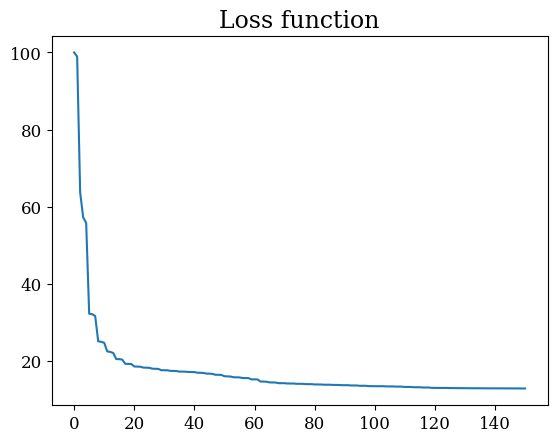

In [29]:
loss_function = np.sum((empirical_moments.T-best_simulated_moments)**2,axis = 0)
loss_function/=loss_function[0]/100


plt.plot(loss_function)
plt.title('Loss function')
# plt.xscale('log')

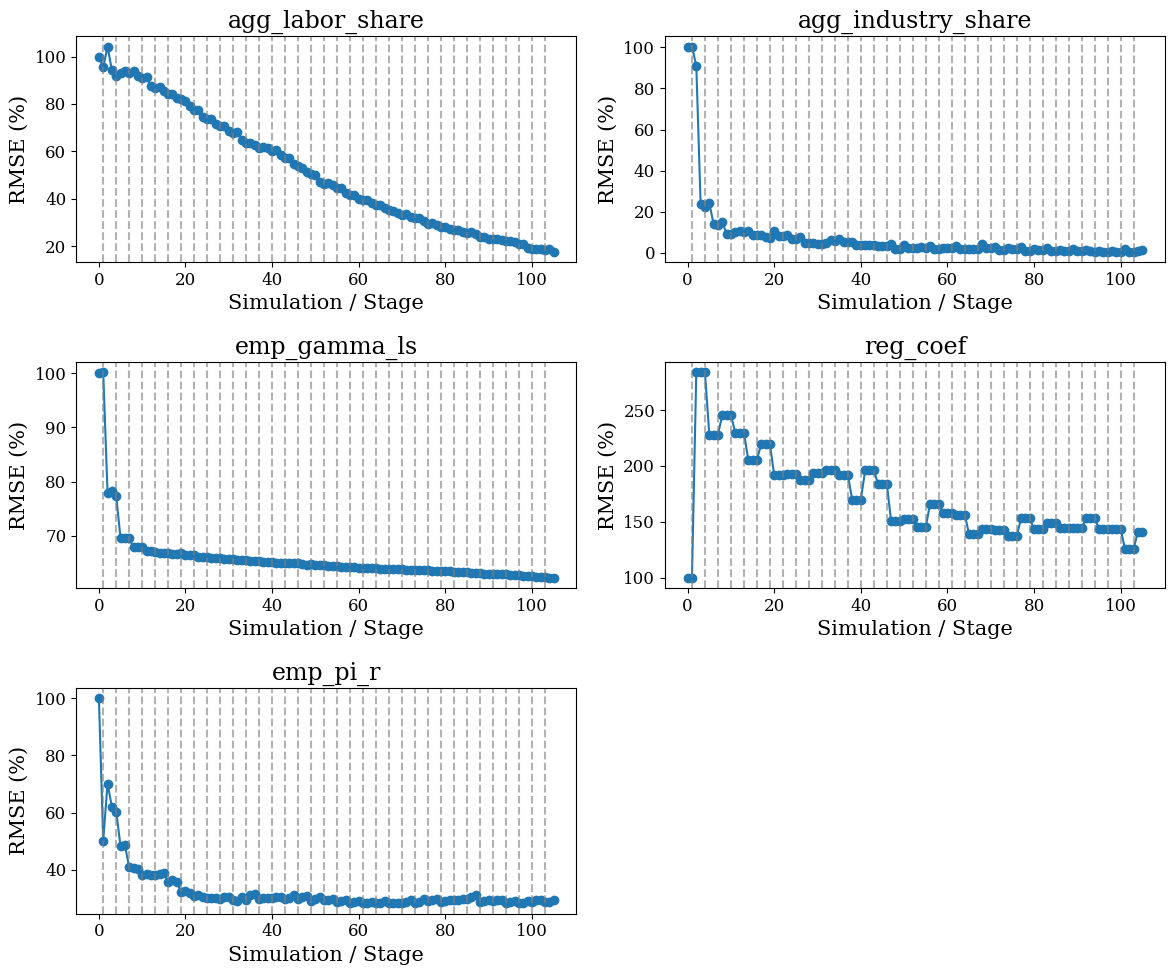

In [30]:
import numpy as np
import matplotlib.pyplot as plt

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2, axis=0))

moment_names = list(empirical_moments_dict.keys())
loss_dict = {}

# --- Compute RMSE and normalize ---
for key in moment_names:
    emp = empirical_moments_dict[key]
    sim = best_simulated_moments_dict[key]  # shape: (*shape_emp, n_sim)
    
    emp_flat = emp.ravel()[:, np.newaxis]          # shape (K, 1)
    sim_flat = sim.reshape(-1, sim.shape[-1])     # shape (K, n_sim)
    
    loss = rmse(emp_flat, sim_flat)
    loss_norm = 100 * loss / loss[0]  # normalize to 100% at stage 0
    loss_dict[key] = loss_norm

# --- Plot in 3x2 subplots ---
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()
n_stages = len(next(iter(loss_dict.values())))  # number of stages

for i, key in enumerate(moment_names):
    ax = axes[i]
    ax.plot(loss_dict[key], marker='o')
    ax.set_title(key)
    ax.set_xlabel("Simulation / Stage")
    ax.set_ylabel("RMSE (%)")
    ax.grid(False)
    
    # Vertical dashed lines every 3 stages, starting at stage 1
    for vline in range(1, n_stages, 3):
        ax.axvline(vline, color='gray', linestyle='--', alpha=0.6)

# Hide unused subplot if less than 6 moments
if len(moment_names) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


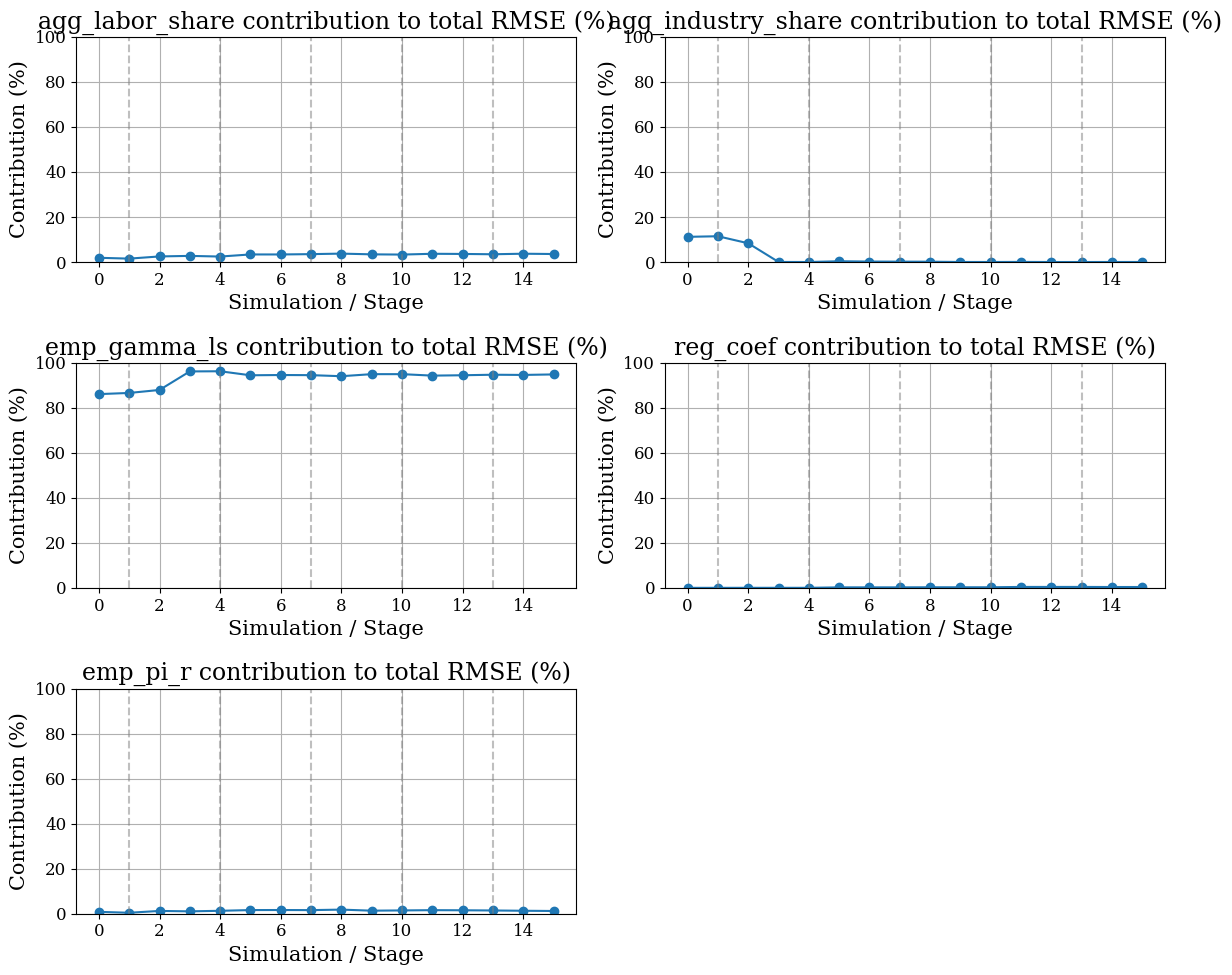

In [23]:
import numpy as np
import matplotlib.pyplot as plt

def squared_error(y_true, y_pred):
    """Compute sum of squared errors along all spatial dimensions."""
    return np.sum((y_true.ravel()[:, np.newaxis] - y_pred.reshape(-1, y_pred.shape[-1]))**2, axis=0)

moment_names = list(empirical_moments_dict.keys())
n_stages = next(iter(best_simulated_moments_dict.values())).shape[-1]

# --- Compute contribution of each type ---
contrib_dict = {key: np.zeros(n_stages) for key in moment_names}
total_se = np.zeros(n_stages)

for key in moment_names:
    emp = empirical_moments_dict[key]
    sim = best_simulated_moments_dict[key]  # shape: (*shape_emp, n_stages)
    
    se = squared_error(emp, sim)  # shape: (n_stages,)
    contrib_dict[key] = se
    total_se += se

# --- Compute % contribution ---
for key in moment_names:
    contrib_dict[key] = 100 * contrib_dict[key] / total_se

# --- Plot ---
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, key in enumerate(moment_names):
    ax = axes[i]
    ax.plot(contrib_dict[key], marker='o')
    ax.set_title(f"{key} contribution to total RMSE (%)")
    ax.set_xlabel("Simulation / Stage")
    ax.set_ylabel("Contribution (%)")
    ax.set_ylim(0, 100)
    ax.grid(True)
    
    # Vertical dashed lines every 3 stages
    for vline in range(1, n_stages, 3):
        ax.axvline(vline, color='gray', linestyle='--', alpha=0.5)

# Hide unused subplot if less than 6 moments
if len(moment_names) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()


## Gamma_ls 

In [ ]:
K = -1

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

emp = empirical_moments_dict['emp_gamma_ls']
best = best_simulated_moments_dict['emp_gamma_ls'][:, :, K]

x = emp.ravel()
y = best.ravel()

# Keep only non-zero empirical observations
mask = (x != 0)
x, y = x[mask], y[mask]

# Bubble sizes (scaled for visibility)
sizes = 300 * (x / x.max())

# Threshold for top 20% empirical values
threshold = np.percentile(x, 80)
top_mask = x >= threshold

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ---- Subplot 1: Full bubble plot ----
axes[0].scatter(
    x, y,
    s=sizes,
    alpha=0.5,
    edgecolor="black"
)

lims_full = [
    min(x.min(), y.min()),
    max(x.max(), y.max())
]
axes[0].plot(lims_full, lims_full, color="black")
axes[0].set_xlim(lims_full)
axes[0].set_ylim(lims_full)

axes[0].set_xlabel(r"Empirical $\gamma_{ls}$")
axes[0].set_ylabel(r"Simulated $\gamma_{ls}$")
axes[0].set_title("Bubble plot – all observations")

# ---- Subplot 2: Top 20% empirical bubble plot ----
axes[1].scatter(
    x[top_mask], y[top_mask],
    s=sizes[top_mask],
    alpha=0.5,
    edgecolor="black"
)

lims_top = [
    min(x[top_mask].min(), y[top_mask].min()),
    max(x[top_mask].max(), y[top_mask].max())
]
axes[1].plot(lims_top, lims_top, color="black")
axes[1].set_xlim(lims_top)
axes[1].set_ylim(lims_top)

axes[1].set_xlabel(r"Empirical $\gamma_{ls}$")
axes[1].set_ylabel(r"Simulated $\gamma_{ls}$")
axes[1].set_title("Bubble plot – top 20% empirical")

plt.tight_layout()
plt.show()


In [ ]:
empirical_moments_dict

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.distributions.empirical_distribution import ECDF

# --- Data ---
emp = empirical_moments_dict['emp_gamma_ls'].ravel()
sim = best_simulated_moments_dict['emp_gamma_ls'][:, :, K].ravel()

# keep positive (and non-zero) moments
emp_nz = emp[emp >= 0.01]
sim_nz = sim[sim >= 0.01]

# --- CDF (log-log) ---
xmin = min(emp_nz.min(), sim_nz.min())
xmax = max(emp_nz.max(), sim_nz.max())
x_vals = np.linspace(xmin, xmax, 300)
x_vals = x_vals[x_vals > 0]

F_emp = ECDF(emp_nz)
F_sim = ECDF(sim_nz)

cdf_emp = F_emp(x_vals)
cdf_sim = F_sim(x_vals)

keep = (cdf_emp > 0) & (cdf_sim > 0)

# --- Histogram threshold ---
x_chi = np.quantile(emp[emp != 0], 0.9)

emp_tail = emp[emp > x_chi]
sim_tail = sim[sim > x_chi]

bins = np.linspace(x_chi, max(emp_tail.max(), sim_tail.max()), 31)

# --- Plot ---
fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# CDF
ax[0].plot(x_vals[keep], cdf_emp[keep], label="Empirical")
ax[0].plot(x_vals[keep], cdf_sim[keep], label="Simulated")
ax[0].set_xscale("log")
ax[0].set_yscale("log")
ax[0].set_xlabel(r"$\gamma_{ls}$")
ax[0].set_ylabel("CDF")
ax[0].set_title("Log-Log CDF of $\gamma_{ls}$")
ax[0].legend()

# Distribution
ax[1].hist(emp_tail, bins=bins, alpha=0.5, label="Empirical")
ax[1].hist(sim_tail, bins=bins, alpha=0.5, label="Simulated")
ax[1].set_title(r"$\gamma_{ls}$ (upper tail)")
ax[1].legend()

plt.tight_layout()
plt.show()


In [ ]:
empirical_moments_dict

In [ ]:

# --- Take the positive, non-zero values ---
emp = empirical_moments_dict['emp_gamma_ls'].ravel()
sim = best_simulated_moments_dict['emp_gamma_ls'][:, :, -1].ravel()

mask = emp > 0.0  # keep regions with non-zero empirical gamma
emp_nz = emp[mask]
sim_nz = sim[mask]

# --- Create DataFrame ---
df = pd.DataFrame({
    "empirical_gamma_ls": emp_nz,
    "simulated_gamma_ls": sim_nz
})

# --- Describe distributions ---
description = df.describe()
print(description)


In [ ]:
tmp = pd.DataFrame(np.ndarray.flatten(empirical_moments_dict['emp_gamma_ls']),columns= ["emp_gamma_ls"])
print(tmp.query("emp_gamma_ls==0").shape)
tmp.query('emp_gamma_ls!= 0').describe()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import powerlaw

# ------------------------------------------------------------------
# 1. Extract non-zero, positive data
# ------------------------------------------------------------------
x = tmp.loc[tmp['emp_gamma_ls'] != 0, 'emp_gamma_ls'].values
x = x[x > 0]

# ------------------------------------------------------------------
# 2. Log–log CCDF (diagnostic)
# ------------------------------------------------------------------
x_sorted = np.sort(x)
ccdf = 1.0 - np.arange(1, len(x_sorted) + 1) / len(x_sorted)

plt.figure()
plt.loglog(x_sorted, ccdf, marker='.', linestyle='none')
plt.xlabel("emp_gamma_ls")
plt.ylabel("P(X ≥ x)")
plt.title("Log–log CCDF of non-zero emp_gamma_ls")
plt.show()

# ------------------------------------------------------------------
# 3. Power-law fit (MLE)
# ------------------------------------------------------------------
fit = powerlaw.Fit(x, discrete=False, verbose=False)

alpha = fit.power_law.alpha
xmin = fit.power_law.xmin

print(f"Power-law alpha: {alpha:.4f}")
print(f"Power-law xmin : {xmin:.4f}")

# ------------------------------------------------------------------
# 4. Goodness-of-fit: power law vs lognormal
# ------------------------------------------------------------------
R, p = fit.distribution_compare('power_law', 'lognormal')

print(f"Likelihood ratio (power law vs lognormal): R = {R:.4f}")
print(f"p-value: {p:.4f}")

# ------------------------------------------------------------------
# 5. Visual comparison of CCDFs
# ------------------------------------------------------------------
fig = fit.plot_ccdf(label='Empirical')
fit.power_law.plot_ccdf(ax=fig, linestyle='--', label='Power law')
fit.lognormal.plot_ccdf(ax=fig, linestyle=':', label='Lognormal')
plt.legend()
plt.show()


# Counterfactuals

## Amplification coefficients


We search to compute 
$$
\begin{aligned}
\mathcal{A}_{r',\sigma}^{\text{Local}}
&= \frac{\sum_{s\neq d} \left(w_s^{r'} w_d^{sr'} w_{r'}^{sr'd}\right)^2 \sigma^{2}_{d,r'}}
{(w_d^{r'})^2 \sigma^{2}_{d,r'}+ \sum_{s\neq d} (w_s^{r'})^2\sigma^{2}_{s,r'}} = \frac{1}{H_h^{r'}} 
\underbrace{\sum_{s\neq d} \left((w_s^{r'})^2 w_d^{sr'}\right)^2 (w_{r'}^{sr'd})^2\sigma_{d,r'}^2}_{H_v^{r'}} .
\end{aligned}
$$

We search to compute 
$$
\begin{aligned}
\mathcal{A}_{r'\sigma}^{\text{All}} 
&= \frac{\sum_{s\neq d} \left(w_s^{r'} w_d^{sr'}\right)^2 \sum_{r}(w_{r}^{sr'd})^2 \sigma^{2}_{d,r}}
{(w_d^{r'})^2 \sigma^{2}_{d,r'}+ \sum_{s\neq d} (w_s^{r'})^2\sigma^{2}_{s,r'}} = \frac{1}{H_h^{r'}} 
\underbrace{\sum_{s\neq d} (w_s^{r'} w_d^{sr'})^2 \sum_{r} (w_{r}^{sr'd})^2 \sigma^{2}_{d,r}}_{H_v^{r'}} .
\end{aligned}
$$

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def compute_amplification_coefficient(
    w_sr_d_sr, 
    w_srd_r, 
    filter_N_upstream_df, 
    sigma_sr, 
    d_sector,
    scope='global',           # 'global' or 'local'
    use_variance=True         # True: use actual variance, False: assume std_sr = 1
):
    """
    Compute the amplification coefficient A_r.
    
    Parameters:
    -----------
    w_sr_d_sr : pd.DataFrame
        DataFrame with columns: ze2010, A129, w_sr, w_d_sr
    w_srd_r : np.array
        Array of shape (S, R', R) with weights w_r^{sr'd}
    filter_N_upstream_df : pd.DataFrame
        DataFrame with columns: A129, ze2010
    sigma_sr : pd.DataFrame
        DataFrame with columns: ze2010, A129, std_sr
    d_sector : str
        The downstream sector code (A129)
    scope : str
        'global': sum over all regions r (local + foreign shocks)
        'local': only r = r' (local shocks only)
    use_variance : bool
        True: use actual std_sr from data
        False: assume std_sr = 1 everywhere
    
    Returns:
    --------
    pd.DataFrame with columns: ze2010, prod_w, w_sr_std_r_2, A_r
    """
    
    # Prepare data
    w_sr_d_sr = w_sr_d_sr.copy()
    w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
    if '_merge' in w_sr_d_sr.columns:
        w_sr_d_sr = w_sr_d_sr.drop(columns="_merge")
    
    sigma_sr = sigma_sr.copy()
    sigma_sr['ze2010'] = sigma_sr['ze2010'].astype(str).str.zfill(4)
    
    # Option: uniform variance
    if not use_variance:
        sigma_sr['std_sr'] = 1
    
    # =========================================================================
    # Step 1: Create df with w_srd_r
    # =========================================================================
    df = filter_N_upstream_df[['A129', 'ze2010']].merge(
        filter_N_upstream_df[['A129', 'ze2010']], 
        on=['A129'], 
        suffixes=['_r_prime', '_r']
    )
    df['w_srd_r'] = np.ndarray.flatten(w_srd_r)
    
    # =========================================================================
    # Step 2: Filter based on scope
    # =========================================================================
    if scope == 'local':
        # Only local transmission: r = r'
        df = df.query('ze2010_r_prime == ze2010_r').copy()
    elif scope == 'global':
        # All transmission: no filter
        pass
    else:
        raise ValueError(f"scope must be 'local' or 'global', got '{scope}'")
    
    # =========================================================================
    # Step 3: Merge with sigma_dr (std of downstream sector d in region r)
    # =========================================================================
    df = df.merge(
        sigma_sr.query('A129 == @d_sector')[['ze2010', 'std_sr']], 
        left_on=['ze2010_r'], 
        right_on=['ze2010']
    ).rename(columns={'std_sr': 'std_dr'})
    
    # =========================================================================
    # Step 4: Compute sum_r (w_r^{sr'd} * sigma_dr)^2
    # =========================================================================
    df['w_srd_r_std_dr_2'] = (df['w_srd_r'] * df['std_dr']) ** 2
    df = df.groupby(['A129', 'ze2010_r_prime'])['w_srd_r_std_dr_2'].sum().reset_index()
    
    # =========================================================================
    # Step 5: Merge with w_sr and w_d_sr
    # =========================================================================
    A_r = w_sr_d_sr.merge(
        df, 
        how='outer', 
        indicator=True, 
        left_on=['A129', 'ze2010'], 
        right_on=['A129', 'ze2010_r_prime']
    )
    A_r['w_srd_r_std_dr_2'] = A_r['w_srd_r_std_dr_2'].fillna(0)
    
    # =========================================================================
    # Step 6: Merge with sigma_sr (std of sector s in region r')
    # =========================================================================
    A_r = A_r.merge(
        sigma_sr.rename(columns={'ze2010': 'ze2010_r_prime'}), 
        on=['ze2010_r_prime', 'A129'], 
        how='left'
    )
    A_r['std_sr'] = A_r['std_sr'].fillna(0)
    
    # =========================================================================
    # Step 7: Compute components
    # =========================================================================
    A_r['w_sr_2'] = A_r['w_sr'] ** 2
    A_r['w_d_sr_2'] = A_r['w_d_sr'] ** 2
    
    # prod_w = (w_s^{r'})^2 * (w_d^{sr'})^2 * sum_r (w_r^{sr'd} * sigma_dr)^2
    A_r['prod_w'] = A_r['w_sr_2'] * A_r['w_d_sr_2'] * A_r['w_srd_r_std_dr_2']
    
    # w_sr_std_r_2 = (w_s^{r'} * sigma_{sr'})^2
    A_r['w_sr_std_r_2'] = (A_r['w_sr'] * A_r['std_sr']) ** 2
    
    # =========================================================================
    # Step 8: Aggregate by region
    # =========================================================================
    result = A_r.groupby('ze2010').agg({
        'prod_w': 'sum', 
        'w_sr_std_r_2': 'sum'
    }).reset_index()
    
    # Amplification coefficient
    result['A_r'] = result['prod_w'] / result['w_sr_std_r_2'] * 100
    
    # Add metadata
    result['scope'] = scope
    result['use_variance'] = use_variance
    
    return result


# =============================================================================
# EXAMPLE USAGE
# =============================================================================
for industry,industry_name in [["auto_23","auto"],['aero',"aero"]]:
    # Load and unpack in one step
    data = load_industry_data(industry, industry_name)
    globals().update(data)  # In a script
    print(d)  # "C29A"

    # Load data
    w_sr_d_sr = pd.read_csv(os.path.join(input_folder, "w_sr_d_sr.csv"))
    sigma_sr = pd.read_csv(os.path.join(input_folder, "sigma_sr.csv"))
    w_srd_r = np.load(os.path.join(folder, "w_srd_r.npy"))

    # Compute all 4 combinations
    A_r_global_var = compute_amplification_coefficient(
        w_sr_d_sr, w_srd_r, filter_N_upstream_df, sigma_sr, d,
        scope='global', use_variance=True
    )

    A_r_global_uniform = compute_amplification_coefficient(
        w_sr_d_sr, w_srd_r, filter_N_upstream_df, sigma_sr, d,
        scope='global', use_variance=False
    )

    A_r_local_var = compute_amplification_coefficient(
        w_sr_d_sr, w_srd_r, filter_N_upstream_df, sigma_sr, d,
        scope='local', use_variance=True
    )

    A_r_local_uniform = compute_amplification_coefficient(
        w_sr_d_sr, w_srd_r, filter_N_upstream_df, sigma_sr, d,
        scope='local', use_variance=False
    )

    # =============================================================================
    # PLOT ALL 4
    # =============================================================================
    from matplotlib.colors import TwoSlopeNorm

    fig, axs = plt.subplots(2, 2, figsize=(20, 16))

    # Compute global vmin/vmax
    all_values = pd.concat([
        A_r_global_var.query('A_r > 0')['A_r'],
        A_r_global_uniform.query('A_r > 0')['A_r'],
        A_r_local_var.query('A_r > 0')['A_r'],
        A_r_local_uniform.query('A_r > 0')['A_r']
    ])
    vmin = all_values.min()
    vmax = all_values.max()
    print(vmax)

    # TwoSlopeNorm centered at 1%
    norm = TwoSlopeNorm(vmin=vmin, vcenter=1, vmax=vmax)

    # Plot with diverging colormap for this specific use case
    plot_map(A_r_global_var, "A_r", axs[0, 0], fig, vmin=vmin, vmax=vmax, add_cbar=False, norm=norm, cmap="RdYlGn")
    plot_map(A_r_global_uniform, "A_r", axs[0, 1], fig, vmin=vmin, vmax=vmax, add_cbar=False, norm=norm, cmap="RdYlGn")
    plot_map(A_r_local_var, "A_r", axs[1, 0], fig, vmin=vmin, vmax=vmax, add_cbar=False, norm=norm, cmap="RdYlGn")
    plot_map(A_r_local_uniform, "A_r", axs[1, 1], fig, vmin=vmin, vmax=vmax, add_cbar=False, norm=norm, cmap="RdYlGn")

    axs[0, 0].set_title("Global + Actual Variance")
    axs[0, 1].set_title("Global + Uniform Variance (σ=1)")
    axs[1, 0].set_title("Local + Actual Variance")
    axs[1, 1].set_title("Local + Uniform Variance (σ=1)")

    # Colorbar
    cbar_ax = fig.add_axes([0.25, 0.02, 0.5, 0.02])
    sm = plt.cm.ScalarMappable(cmap="RdYlGn", norm=norm)
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cbar.set_label("A_r (%)")

    fig.suptitle(industry, y=0.98)
    plt.subplots_adjust(bottom=0.08)
    plt.show()


## Shock to a region

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def compute_V_r(w_sr_d_sr, w_srd_r, filter_N_upstream_df, sigma_sr, d_sector):
    """
    Compute total variance V_{r'} = prod_w + w_sr_std_r_2 for each region.
    
    Returns:
    --------
    pd.DataFrame with columns: ze2010, V_r, prod_w, w_sr_std_r_2
    """
    
    w_sr_d_sr = w_sr_d_sr.copy()
    w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
    
    sigma_sr = sigma_sr.copy()
    sigma_sr['ze2010'] = sigma_sr['ze2010'].astype(str).str.zfill(4)
    
    # Create df with w_srd_r
    df = filter_N_upstream_df[['A129', 'ze2010']].merge(
        filter_N_upstream_df[['A129', 'ze2010']], 
        on=['A129'], 
        suffixes=['_r_prime', '_r']
    )
    df['w_srd_r'] = np.ndarray.flatten(w_srd_r)
    
    # =========================================================================
    # Step 1: Compute sum_r (w_r^{sr'd} * sigma_dr)^2 for each (sector s, region r')
    # =========================================================================
    # Merge with sigma_dr (std of downstream sector d in region r)
    df = df.merge(
        sigma_sr.query('A129 == @d_sector')[['ze2010', 'std_sr']], 
        left_on=['ze2010_r'], 
        right_on=['ze2010']
    ).rename(columns={'std_sr': 'std_dr'})
    
    df['w_srd_r_std_dr_2'] = (df['w_srd_r'] * df['std_dr']) ** 2
    df = df.groupby(['A129', 'ze2010_r_prime'])['w_srd_r_std_dr_2'].sum().reset_index()
    
    # =========================================================================
    # Step 2: Merge with w_sr and w_d_sr
    # =========================================================================
    A_r = w_sr_d_sr.merge(
        df, 
        how='outer', 
        left_on=['A129', 'ze2010'], 
        right_on=['A129', 'ze2010_r_prime']
    )
    A_r['w_srd_r_std_dr_2'] = A_r['w_srd_r_std_dr_2'].fillna(0)
    
    # =========================================================================
    # Step 3: Merge with sigma_sr (std of sector s in region r')
    # =========================================================================
    A_r = A_r.merge(
        sigma_sr.rename(columns={'ze2010': 'ze2010_r_prime'}), 
        on=['ze2010_r_prime', 'A129'], 
        how='left'
    )
    A_r['std_sr'] = A_r['std_sr'].fillna(0)
    
    # =========================================================================
    # Step 4: Compute components
    # =========================================================================
    A_r['w_sr_2'] = A_r['w_sr'] ** 2
    A_r['w_d_sr_2'] = A_r['w_d_sr'] ** 2
    
    # prod_w = (w_s^{r'})^2 * (w_d^{sr'})^2 * sum_r (w_r^{sr'd} * sigma_dr)^2
    A_r['prod_w'] = A_r['w_sr_2'] * A_r['w_d_sr_2'] * A_r['w_srd_r_std_dr_2']
    
    # w_sr_std_r_2 = (w_s^{r'} * sigma_{sr'})^2
    A_r['w_sr_std_r_2'] = (A_r['w_sr'] * A_r['std_sr']) ** 2
    
    # =========================================================================
    # Step 5: Sum over sectors for each region
    # =========================================================================
    V_r = A_r.groupby('ze2010').agg({
        'prod_w': 'sum', 
        'w_sr_std_r_2': 'sum'
    }).reset_index()
    
    # Total variance
    V_r['V_r'] = V_r['prod_w'] + V_r['w_sr_std_r_2']
    
    return V_r


def compute_shock_propagation(shocked_ze, w_sr_d_sr, w_srd_r, filter_N_upstream_df, 
                               sigma_sr, d_sector):
    """
    Compute how a variance shock in a specific region propagates to all other regions.
    
    Parameters:
    -----------
    shocked_ze : str
        The ze2010 code of the shocked region (r_bar)
    w_sr_d_sr : pd.DataFrame
        DataFrame with columns: ze2010, A129, w_sr, w_d_sr
    w_srd_r : np.array
        Array of shape (S, R', R) with weights w_r^{sr'd}
    filter_N_upstream_df : pd.DataFrame
        DataFrame with columns: A129, ze2010
    sigma_sr : pd.DataFrame
        DataFrame with columns: ze2010, A129, std_sr
    d_sector : str
        The downstream sector code (A129)
    
    Returns:
    --------
    pd.DataFrame with columns:
        - ze2010: region code
        - dV_dsigma: ∂V_{r'}/∂σ²_{d,r_bar}
        - transmission: IO transmission component
        - direct: direct effect (only for shocked region)
        - V_r: total variance in region
        - elasticity: ∂ln(V_{r'})/∂ln(σ²_{d,r_bar})
    """
    
    # Prepare data
    w_sr_d_sr = w_sr_d_sr.copy()
    w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
    
    sigma_sr = sigma_sr.copy()
    sigma_sr['ze2010'] = sigma_sr['ze2010'].astype(str).str.zfill(4)
    
    shocked_ze = str(shocked_ze).zfill(4)
    
    # Create df with w_srd_r
    df = filter_N_upstream_df[['A129', 'ze2010']].merge(
        filter_N_upstream_df[['A129', 'ze2010']], 
        on=['A129'], 
        suffixes=['_r_prime', '_r']
    )
    df['w_srd_r'] = np.ndarray.flatten(w_srd_r)
    
    # =========================================================================
    # TRANSMISSION CHANNEL: sum_s (w_s^{r'})^2 (w_d^{sr'})^2 (w_{r_bar}^{sr'd})^2
    # =========================================================================
    
    # Filter for r = shocked region
    df_shocked = df[df['ze2010_r'] == shocked_ze].copy()
    
    # Merge with w_sr and w_d_sr
    df_shocked = df_shocked.merge(
        w_sr_d_sr[['A129', 'ze2010', 'w_sr', 'w_d_sr']], 
        left_on=['A129', 'ze2010_r_prime'], 
        right_on=['A129', 'ze2010'],
        how='left'
    )
    
    # Compute: (w_s^{r'})^2 * (w_d^{sr'})^2 * (w_{r_bar}^{sr'd})^2
    df_shocked['transmission_s'] = (
        (df_shocked['w_sr'] ** 2) * 
        (df_shocked['w_d_sr'] ** 2) * 
        (df_shocked['w_srd_r'] ** 2)
    )
    
    # Sum over sectors s
    result = df_shocked.groupby('ze2010_r_prime')['transmission_s'].sum().reset_index()
    result.columns = ['ze2010', 'transmission']
    
    # =========================================================================
    # DIRECT CHANNEL: (w_d^{r_bar})^2 * 1_{r' = r_bar}
    # =========================================================================
    
    w_d_rbar_df = w_sr_d_sr[
        (w_sr_d_sr['A129'] == d_sector) & 
        (w_sr_d_sr['ze2010'] == shocked_ze)
    ]
    
    if len(w_d_rbar_df) > 0:
        w_d_rbar = w_d_rbar_df['w_sr'].values[0]
        direct_effect = w_d_rbar ** 2
    else:
        direct_effect = 0
    
    result['direct'] = 0.0
    result.loc[result['ze2010'] == shocked_ze, 'direct'] = direct_effect
    
    # =========================================================================
    # TOTAL MARGINAL EFFECT
    # =========================================================================
    result['dV_dsigma'] = result['transmission'] + result['direct']
    
    # =========================================================================
    # COMPUTE V_r = prod_w + w_sr_std_r_2
    # =========================================================================
    V_r = compute_V_r(w_sr_d_sr, w_srd_r, filter_N_upstream_df, sigma_sr, d_sector)
    result = result.merge(V_r[['ze2010', 'V_r', 'prod_w', 'w_sr_std_r_2']], on='ze2010', how='left')
    
    # =========================================================================
    # ELASTICITY
    # Get sigma^2 for shocked region
    # =========================================================================
    sigma_shocked_df = sigma_sr[
        (sigma_sr['A129'] == d_sector) & 
        (sigma_sr['ze2010'] == shocked_ze)
    ]
    
    if len(sigma_shocked_df) > 0:
        sigma2_shocked = sigma_shocked_df['std_sr'].values[0] ** 2
    else:
        sigma2_shocked = sigma_sr.query('A129 == @d & ze2010 == @shocked_ze').std_sr.values[0]**2
    
    # Elasticity: (σ²_{d,r_bar} / V_{r'}) * ∂V_{r'}/∂σ²_{d,r_bar}
    result['elasticity'] = (sigma2_shocked / result['V_r']) * result['dV_dsigma']*100
    
    
    return result



In [ ]:

# =============================================================================
# EXAMPLE USAGE
# =============================================================================

# Load data
w_sr_d_sr = pd.read_csv(os.path.join(input_folder, "w_sr_d_sr.csv"))
w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
if '_merge' in w_sr_d_sr.columns:
    w_sr_d_sr = w_sr_d_sr.drop(columns="_merge")

sigma_sr = pd.read_csv(os.path.join(input_folder, "sigma_sr.csv"))
sigma_sr['ze2010'] = sigma_sr['ze2010'].astype(str).str.zfill(4)

w_srd_r = np.load(os.path.join(folder, "w_srd_r.npy"))  # S x R' x R
ze_to_shock = {"1101":"Paris","0061":"Toulouse","9310":"Marseille - Aubagne","5203":"Nantes","8301":"Montluçon","1115":"Évry-Courcouronnes",
"1116":"Saclay"}

# Define the shocked region
shocked_ze = "1116"  # Example: shock toulouse

# Compute shock propagation
result = compute_shock_propagation(
    shocked_ze=shocked_ze,
    w_sr_d_sr=w_sr_d_sr,
    w_srd_r=w_srd_r,
    filter_N_upstream_df=filter_N_upstream_df,
    sigma_sr=sigma_sr,
    d_sector=d
)

# Display top affected regions
print(f"\n{'='*60}")
print(f"Shock propagation from region {shocked_ze}")
print(f"{'='*60}\n")
print(result.sort_values('dV_dsigma', ascending=False).head(20))

# =============================================================================
# PLOTS
# =============================================================================



fig, axs = plt.subplots(1, 1, figsize=(15, 10))
plot_map(result, "elasticity", axs, fig,vmin=0.001,ze_shocked= shocked_ze)
axs.set_title(f"∂ln(V_r') / ∂ln(σ²_d,{ze_to_shock[shocked_ze] if shocked_ze in ze_to_shock.keys() else shocked_ze}) (Elasticity)")
plt.tight_layout()
plt.show()




In [ ]:
ze_to_shock = {"1101":"Paris","0061":"Toulouse","9310":"Marseille - Aubagne","5203":"Nantes","8301":"Montluçon","1115":"Évry-Courcouronnes",
    "1116":"Saclay"}

fig,axs = plt.subplots(1,2,figsize = (20,15))
i = 0
axs = axs.flatten()
for shocked_ze,industry,industry_name in [["0061",'aero',"aero"],["1116","auto_23","auto"]]:
    # Load and unpack in one step
    data = load_industry_data(industry,industry_name)
    globals().update(data)  # In a script
    print(d)  # "C29A"

        
    # Load data
    w_sr_d_sr = pd.read_csv(os.path.join(input_folder, "w_sr_d_sr.csv"))
    w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
    if '_merge' in w_sr_d_sr.columns:
        w_sr_d_sr = w_sr_d_sr.drop(columns="_merge")

    sigma_sr = pd.read_csv(os.path.join(input_folder, "sigma_sr.csv"))
    sigma_sr['ze2010'] = sigma_sr['ze2010'].astype(str).str.zfill(4)

    w_srd_r = np.load(os.path.join(folder, "w_srd_r.npy"))  # S x R' x R
 

    # Define the shocked region

    # Compute shock propagation
    result = compute_shock_propagation(
        shocked_ze=shocked_ze,
        w_sr_d_sr=w_sr_d_sr,
        w_srd_r=w_srd_r,
        filter_N_upstream_df=filter_N_upstream_df,
        sigma_sr=sigma_sr,
        d_sector=d
    )

    plot_map(result, "elasticity", axs[i], fig,vmin=0.001,ze_shocked= shocked_ze)
    axs[i].set_title(f"{industry_name}: shock on {ze_to_shock[shocked_ze] if shocked_ze in ze_to_shock.keys() else shocked_ze}")

    i+=1
plt.tight_layout()
plt.show()




## Elasticity and distance

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def analyze_shock_by_distance(result, distance_matrix, shocked_ze):
    """
    Analyze how shock elasticity decays with distance from the shocked region.
    """
    
    result = result.copy()
    result['ze2010'] = result['ze2010'].astype(str).str.zfill(4)
    shocked_ze = str(shocked_ze).zfill(4)
    
    # Ensure distance matrix has proper index/columns
    distance_matrix = distance_matrix.copy()
    distance_matrix.index = distance_matrix.index.astype(str).str.zfill(4)
    distance_matrix.columns = distance_matrix.columns.astype(str).str.zfill(4)
    
    # Extract distances from shocked region to all others
    if shocked_ze in distance_matrix.index:
        distances = distance_matrix.loc[shocked_ze].reset_index()
        distances.columns = ['ze2010', 'distance']
    else:
        raise ValueError(f"Shocked region {shocked_ze} not found in distance matrix")
    
    # Merge with elasticity results
    result = result.merge(distances, on='ze2010', how='left')
    
    return result


def plot_elasticity_by_bins(result, shocked_ze, bins=[20, 50, 100, 150, 200], figsize=(10, 6)):
    """
    Plot average elasticity by custom distance bins.
    
    Parameters:
    -----------
    result : pd.DataFrame
        Output from analyze_shock_by_distance
    shocked_ze : str
        The shocked region code
    bins : list
        List of bin edges. Creates bins: [0, bins[0]], (bins[0], bins[1]], ..., (bins[-1], +∞)
    figsize : tuple
        Figure size
    
    Returns:
    --------
    fig, ax, binned_df
    """
    
    shocked_ze = str(shocked_ze).zfill(4)
    
    # Exclude shocked region
    other_points = result[result['ze2010'] != shocked_ze].copy()
    
    # Create bin edges: [0] + bins + [+∞]
    bin_edges = [0] + bins + [np.inf]
    
    # Create labels
    labels = []
    for i in range(len(bin_edges) - 1):
        if bin_edges[i+1] == np.inf:
            labels.append(f'>{bin_edges[i]}')
        else:
            labels.append(f'{bin_edges[i]}-{bin_edges[i+1]}')
    
    # Assign bins
    other_points['distance_bin'] = pd.cut(
        other_points['distance'], 
        bins=bin_edges, 
        labels=labels,
        include_lowest=True
    )
    
    # Compute statistics by bin
    binned = other_points.groupby('distance_bin', observed=True).agg({
        'elasticity': ['mean', 'std', 'count'],
        'distance': 'mean'
    }).reset_index()
    
    binned.columns = ['distance_bin', 'mean_elasticity', 'std_elasticity', 'count', 'mean_distance']
    
    # Plot
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    
    x_pos = np.arange(len(binned))
    
    ax.bar(x_pos, binned['mean_elasticity'], 
           yerr=binned['std_elasticity'], 
           capsize=5, 
           color='steelblue', 
           alpha=0.8,
           edgecolor='black')
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(binned['distance_bin'], fontsize=11)
    ax.set_xlabel('Distance (km)', fontsize=12)
    ax.set_ylabel('Mean Elasticity $\\bar{\\epsilon}(d)$', fontsize=12)
    ax.set_title(f'Average Elasticity by Distance from Region {shocked_ze}', fontsize=14)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add count labels on top of bars
    for i, (val, count) in enumerate(zip(binned['mean_elasticity'], binned['count'])):
        ax.annotate(f'n={count}', xy=(i, val + binned['std_elasticity'].iloc[i]), 
                    ha='center', va='bottom', fontsize=9, color='gray')
    
    plt.tight_layout()
    
    return fig, ax, binned


# =============================================================================
# EXAMPLE USAGE
# =============================================================================

# Load data
w_sr_d_sr = pd.read_csv(os.path.join(input_folder, "w_sr_d_sr.csv"))
w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
if '_merge' in w_sr_d_sr.columns:
    w_sr_d_sr = w_sr_d_sr.drop(columns="_merge")

sigma_sr = pd.read_csv(os.path.join(input_folder, "sigma_sr.csv"))
sigma_sr['ze2010'] = sigma_sr['ze2010'].astype(str).str.zfill(4)

w_srd_r = np.load(os.path.join(folder, "w_srd_r.npy"))

# Load distance matrix
distance_matrix = np.load(os.path.join(input_folder, "distances.npy"))
regions = np.sort(filter_N_upstream_df.ze2010.unique())
distance_matrix = pd.DataFrame(distance_matrix, index=regions, columns=regions)

# Define shocked region
shocked_ze = "0061"

# Step 1: Compute shock propagation
result = compute_shock_propagation(
    shocked_ze=shocked_ze,
    w_sr_d_sr=w_sr_d_sr,
    w_srd_r=w_srd_r,
    filter_N_upstream_df=filter_N_upstream_df,
    sigma_sr=sigma_sr,
    d_sector=d
)

# Step 2: Add distance information
result = analyze_shock_by_distance(result, distance_matrix, shocked_ze)

# Step 3: Plot by custom bins
bins = [20, 50, 100, 150, 200]
fig, ax, binned_df = plot_elasticity_by_bins(result, shocked_ze, bins=bins)
plt.show()

# Display binned statistics
print(binned_df)

In [ ]:
ze_to_shock = {
    "1101": "Paris",
    "0061": "Toulouse",
    "9310": "Marseille - Aubagne",
    "5203": "Nantes",
    "8301": "Montluçon",
    "1115": "Évry-Courcouronnes",
    "1116": "Saclay"
}

# Load distance matrix (only once)
distance_matrix = np.load(os.path.join(input_folder, "distances.npy"))
regions = np.sort(filter_N_upstream_df.ze2010.unique())
distance_matrix = pd.DataFrame(distance_matrix, index=regions, columns=regions)

# Define triplets
triplets = [
    ["0061", 'aero', "aero"],
    ["1116", "auto_23", "auto"]
]

# Define distance bins
bins = [20, 50, 100, 150, 200]

# Create subplots: n_rows x 2 columns
n_rows = len(triplets)
fig, axs = plt.subplots(n_rows, 2, figsize=(20, 8 * n_rows))

# Handle case of single row
if n_rows == 1:
    axs = axs.reshape(1, -1)

for i, (shocked_ze, industry, industry_name) in enumerate(triplets):
    
    # Load industry data
    data = load_industry_data(industry, industry_name)
    globals().update(data)
    print(d)
    
    # Load data
    w_sr_d_sr = pd.read_csv(os.path.join(input_folder, "w_sr_d_sr.csv"))
    w_sr_d_sr['ze2010'] = w_sr_d_sr['ze2010'].astype(str).str.zfill(4)
    if '_merge' in w_sr_d_sr.columns:
        w_sr_d_sr = w_sr_d_sr.drop(columns="_merge")

    sigma_sr = pd.read_csv(os.path.join(input_folder, "sigma_sr.csv"))
    sigma_sr['ze2010'] = sigma_sr['ze2010'].astype(str).str.zfill(4)

    w_srd_r = np.load(os.path.join(folder, "w_srd_r.npy"))

    # Compute shock propagation
    result = compute_shock_propagation(
        shocked_ze=shocked_ze,
        w_sr_d_sr=w_sr_d_sr,
        w_srd_r=w_srd_r,
        filter_N_upstream_df=filter_N_upstream_df,
        sigma_sr=sigma_sr,
        d_sector=d
    )

    # Add distance information
    result = analyze_shock_by_distance(result, distance_matrix, shocked_ze)

    # =========================================================================
    # LEFT PLOT: Map
    # =========================================================================
    plot_map(result, "elasticity", axs[i, 0], fig, vmin=0.001, ze_shocked=shocked_ze)
    region_name = ze_to_shock.get(shocked_ze, shocked_ze)
    axs[i, 0].set_title(f"{industry_name}: shock on {region_name}", fontsize=14)

    # =========================================================================
    # RIGHT PLOT: Elasticity by distance bins
    # =========================================================================
    ax_right = axs[i, 1]
    
    shocked_ze_str = str(shocked_ze).zfill(4)
    other_points = result[result['ze2010'] != shocked_ze_str].copy()
    
    # Create bin edges
    bin_edges = [0] + bins + [np.inf]
    labels = []
    for j in range(len(bin_edges) - 1):
        if bin_edges[j + 1] == np.inf:
            labels.append(f'>{bin_edges[j]}')
        else:
            labels.append(f'{bin_edges[j]}-{bin_edges[j + 1]}')
    
    other_points['distance_bin'] = pd.cut(
        other_points['distance'],
        bins=bin_edges,
        labels=labels,
        include_lowest=True
    )
    
    # Compute statistics by bin
    binned = other_points.groupby('distance_bin', observed=True).agg({
        'elasticity': ['mean', 'std', 'count'],
        'distance': 'mean'
    }).reset_index()
    binned.columns = ['distance_bin', 'mean_elasticity', 'std_elasticity', 'count', 'mean_distance']
    
    # Bar plot
    x_pos = np.arange(len(binned))
    ax_right.bar(x_pos, binned['mean_elasticity'],
                 yerr=binned['std_elasticity'],
                 capsize=5,
                 color='steelblue',
                 alpha=0.8,
                 edgecolor='black')
    
    ax_right.set_xticks(x_pos)
    ax_right.set_xticklabels(binned['distance_bin'], fontsize=10)
    ax_right.set_xlabel('Distance (km)', fontsize=12)
    ax_right.set_ylabel('Mean Elasticity $\\bar{\\epsilon}(d)$', fontsize=12)
    ax_right.set_title(f'{industry_name}: Elasticity decay from {region_name}', fontsize=14)
    ax_right.grid(True, alpha=0.3, axis='y')
    
    # Add count labels
    for j, (val, count, std) in enumerate(zip(binned['mean_elasticity'], binned['count'], binned['std_elasticity'])):
        ax_right.annotate(f'n={count}', xy=(j, val + std),
                          ha='center', va='bottom', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

# ## Output Structure

# For each triplet, you get a **row** with:

# | Left (Column 0) | Right (Column 1) |
# |-----------------|------------------|
# | Map of elasticity $\epsilon_{r'}$ | Bar chart of $\bar{\epsilon}(d)$ by distance bins |

# So for 2 triplets, you get a **2×2 grid**:
# ```
# Row 0: [Map: aero shock on Toulouse] [Bar chart: aero elasticity decay]
# Row 1: [Map: auto shock on Saclay]   [Bar chart: auto elasticity decay]

# Test

In [135]:
best_params = {i:unpack_params(np.load(os.path.join(folder,file,"best_params.npy")),R_downstream=emp_pi_r.shape[0] + 1)['productivity'] for i,file in enumerate(["0"] + [f'epoch_{i}/{1 + 3*(i-1)}' for i in range(1,30)])}
sim_pi_r = {i:list(np.load(os.path.join(folder,file,"pi_r.npy"))) for  i,file in enumerate(["0"] + [f'epoch_{i}/{1 + 3*(i-1)}' for i in range(1,30)])}

best_params[0]
productivity  = np.array([i.reshape(-1) for i in best_params.values()])

current_pi_r = pi_r.query('pi_r!= 0').pi_r.values
productivity = productivity[:,np.argsort(current_pi_r)]


sim_pi_r  = np.array([[1-np.sum(i)] + i for i in sim_pi_r.values()])

sim_pi_r = sim_pi_r[:,np.argsort(current_pi_r)]
(sim_pi_r)[:,-3:]


reg_coef



array([ 0.00223031, -0.00129359, -0.00311532, -0.00471691, -0.00392816])

# Suppliers map

In [ ]:
sim_suppliers = np.load(os.path.join(folder,"suppliers.npy")) # S x R' x R
sim_suppliers = sim_suppliers.astype(int)
sim_suppliers = np.sum(sim_suppliers,axis = 1)/np.sum(sim_suppliers)
emp_suppliers = np.load(os.path.join(input_folder,"N_rs.npy")) # Number of upstream per region. 

upstream_A129_region = pd.read_csv(os.path.join(input_folder,"upstream_A129_region.csv")).query('ze2010 != 9999')
upstream_A129_region['ze2010']  = upstream_A129_region.ze2010.astype(str).str.zfill(4)
df = filter_N_upstream_df[['A129',"ze2010"]]
df["sim_suppliers"] = np.ndarray.flatten(sim_suppliers)
df["emp_suppliers"] = np.ndarray.flatten(emp_suppliers)/np.sum(emp_suppliers)
df["N_rs"] = np.ndarray.flatten(emp_suppliers)
plt.scatter(df.emp_suppliers,df.sim_suppliers)

In [ ]:
df.sort_values(by = 'emp_suppliers')